In [1]:
import jax
import jax.numpy as jnp
import optax
import flax.linen as nn
from flax.training import train_state
from flax.linen import initializers
from flax.training.common_utils import onehot
from flax.training import checkpoints
from flax import jax_utils
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import math
from itertools import islice, cycle
from flax.training.train_state import TrainState
from flax import struct
from typing import Union, Callable
from optax import tree_utils as otu

import sys
import os

# Add the parent directory of precond_gd to the Python path
# sys.path.append(os.path.abspath(os.path.join(os.path.expanduser('~'), 'precond-gd')))
relative_path = os.path.join('..', '..')  # Go up two levels to reach precond-gd
sys.path.append(os.path.abspath(relative_path))

from precond_gd.utils import datasets

jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')

# import json
import pickle
import orbax # This doesn't work very well 
from flax.training import checkpoints # So does this


2025-09-15 12:23:15.564333: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757964196.736089   19192 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757964197.277155   19192 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1757964199.156294   19192 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757964199.156326   19192 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757964199.156330   19192 computation_placer.cc:177] computation placer alr

# MNIST Grokking 

We want to show that MNIST groks with some parameter and AdamW, but applying the different preconditioners it reduces the distances

## Data and model definition

We import the MNIST dataset and create the necessary generators and model structures; this doesn't change in the structure

In [2]:
# Don't use TFDS because SSL sometimes is dumb on site; use Jax loader instead
# https://github.com/jax-ml/jax/blob/main/examples/datasets.py

train_images, train_labels, test_images, test_labels = datasets.mnist()
train_images, train_labels, test_images, test_labels = jnp.array(train_images), jnp.array(train_labels), jnp.array(test_images), jnp.array(test_labels)

# np.random.seed(0)
# Create a generator that yields shuffled batches of data without repetition until an epoch is complete
def data_generator(images, labels, batch_size):
    num_samples = images.shape[0]
    # while True:
    #     # Shuffle the data at the beginning of each epoch
    indices = np.random.permutation(num_samples)
    # indices = np.arange(num_samples)
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = indices[start_idx:end_idx]
        yield {'image': images[batch_indices], 'label': labels[batch_indices]}

downloaded https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz to /tmp/jax_example_data/
downloaded https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz to /tmp/jax_example_data/
downloaded https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz to /tmp/jax_example_data/
downloaded https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz to /tmp/jax_example_data/


In [3]:

# Model definition (Linen)
class MLP(nn.Module):
    depth: int
    width: int

    @nn.compact
    def __call__(self, x):
        for i in range(self.depth):
            if i == 0:
                x = nn.Dense(self.width,
                             dtype=jnp.float64,
                             kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(784), maxval=1 / jnp.sqrt(784)),
                             bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(784), maxval=1 / jnp.sqrt(784))
                            )(x)
            elif i == self.depth - 1:
                x = nn.Dense(10, 
                             dtype=jnp.float64,
                            kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200)),
                            bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200))
                                )(x)
            else:
                x = nn.Dense(self.width, 
                             dtype=jnp.float64,
                            kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200)),
                            bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200))
                            )(x)
            if i < self.depth - 1:
                x = nn.relu(x)
        return x



## Jax data structures

WE use a subclassed TrainState so that we can use more advanced optax transformations rather than just Adam/SGD etc. 

In [4]:

# The TrainState in Flax doesn't allow for more complex optimziers
# Thus we subclass it and insert the way we need to update 
class MyTrainState(TrainState):
    tx: optax.GradientTransformationExtraArgs = struct.field(pytree_node=False)
    def apply_gradients(self, *, grads, **kwargs):
        value, value_fn, x, labels = kwargs['value'], kwargs['value_fn'], kwargs['x'], kwargs['labels']
        updates, new_opt_state = self.tx.update(
            grads,
            self.opt_state,
            self.params,
            value=value,
            grad=grads,
            value_fn=value_fn,
            x=x,
            labels=labels
        )
        new_params_with_opt = optax.apply_updates(
            self.params, updates)
        return self.replace(
          step=self.step + 1,
          params=new_params_with_opt,
          opt_state=new_opt_state,
        )
        # print(new_params_with_opt)
    
def create_train_state(rng, model, learning_rate, weight_decay: float=1e-2, initialization_scale: float=1.0, 
                      optimizer: Union[str, optax._src.base.GradientTransformationExtraArgs] = 'adamw' ):
    params = model.init(rng, jnp.ones([1, 784], dtype=jnp.float64,))
    params = jax.tree.map(lambda p: initialization_scale * p, params)
    tx = optax.adamw(learning_rate, weight_decay=weight_decay)

    if optimizer == 'adamw':
        tx = optax.adamw(learning_rate, weight_decay=weight_decay)
    elif optimizer == 'adam':
        tx = optax.adam(learning_rate)
    elif optimizer == 'sgd':
        tx = optax.sgd(learning_rate)
    else: 
        print('Custom optimizer')
        tx = optimizer
        
    # tx = optax.chain(
    #     optax.sgd(learning_rate),
    #     optax.scale_by_backtracking_linesearch(max_backtracking_steps=5, decrease_factor=.5)
    # )
    return MyTrainState.create(apply_fn=model.apply, params=params, tx=tx)


## Parameters

These are parameters from the Omnigrok paper/Github repo. 

In [5]:
### Choose experiment parameters
train_points = 1000
optimization_steps = 100000
batch_size = 200
weight_decay = 0.01
lr = 1e-3
initialization_scale = 8.0
depth = 2             # the number of nn.Linear modules in the model
width = 250
num_runs = 5


# Helper function here
def combine_switch(first_run, second_run): 
    """
    train_losses, test_losses, train_accuracies, 
            test_accuracies, log_steps, losses, state.params, norms
    """
    combined_out = [
        first_run[0] + second_run[0], # Train losses
        first_run[1] + second_run[1], # Test losses
        first_run[2] + second_run[2], # Train acc
        first_run[3] + second_run[3], # Test acc
        jnp.concat((jnp.array(first_run[4]),
                   jnp.array(second_run[4]) +  2* first_run[4][-1] - first_run[4][-2])), # log steps (TODO)
        first_run[5] + second_run[5], # losses
        second_run[6], # Keep last params 
        first_run[7] + second_run[7] # norms
    ]

    return combined_out

## Training Loop

Make the training loop; we make two of them: one without any sort of precond operator, and the other with it. 
These should be transferrable; e.g. can move from one to the other using differing state

In [6]:
def train_mnist_noprecond(model, state, optimization_steps: int=100000, trian_points: int=1000, 
                          batch_size: int = 200, log_freq: int = None):
    # Logs
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    log_steps = []
    losses = []
    norms = []

    @jax.jit
    def loss_fn_wrapper(params, x, labels):
        logits = model.apply(params, x)
        loss = jnp.mean((logits - labels) ** 2)
        return loss

    @jax.jit
    def batch_loss_accuracy(params, x, labels):
        # Eval model 
        logits = model.apply(params, x)
        loss = jnp.mean((logits - labels) ** 2)

        # Get accuracy 
        predicted_labels = jnp.argmax(logits, axis=1) # shape (200,)
        correct = jnp.sum(predicted_labels == labels @ jnp.arange(10)) # convert labels (50, 10) to (50,)

        return  loss, correct
        
    def compute_loss_and_accuracy(params, dataset):
        """Computes mean loss of `model` on `dataset`."""
        total_loss = 0
        total_points = 0
        correct = 0

        for batch in dataset:
            x, labels = batch['image'], batch['label']
        
            batch_loss, batch_accuracy = batch_loss_accuracy(params, x, labels)

            total_loss += batch_loss
            correct += batch_accuracy
            total_points += x.shape[0]
        return total_loss / total_points, (correct / total_points)

    # For efficiency, calculate the gradient before hand
    grad_fn = jax.value_and_grad(loss_fn_wrapper)
    test_ds = data_generator(test_images, test_images, batch_size)

    steps = 0
    break_outer = False

    if not log_freq:
        log_freq = math.ceil(optimization_steps / 150)
    with tqdm(total=optimization_steps) as pbar:
        # Loop over each epoch (approximate total number of batch steps)
        for epoch in range(optimization_steps // (train_points // batch_size) + 1):

            # Recreate the training generator for each epoch for shuffle
            train_ds = data_generator(train_images[0:train_points], train_labels[0:train_points], batch_size)
            for batch in train_ds:
                x, labels = batch['image'], batch['label']

                # Store the 
                if (steps < 15) or (steps < 150 and steps % 10 == 0) or (steps % log_freq == 0):
                    epoch_loss, epoch_acc = compute_loss_and_accuracy(
                            state.params, data_generator(train_images[0:train_points], train_labels[0:train_points], batch_size=50)
                    )
                    train_losses.append(
                        epoch_loss
                    )
                    train_accuracies.append(
                        epoch_acc
                    )
        
                    epoch_loss, epoch_acc = compute_loss_and_accuracy(
                            state.params, data_generator(test_images, test_labels, batch_size=50)
                    )
                    test_losses.append(
                        epoch_loss
                    )
                    test_accuracies.append(
                        epoch_acc
                    )
        
                    log_steps.append(steps)
                    params_leaves = jax.tree_util.tree_leaves(state.params)
                    norms.append(jnp.linalg.norm(jnp.concatenate([jnp.ravel(p) for p in params_leaves])))
                    # last_layer_norms.append(jnp.linalg.norm(state.params['Dense_2']['kernel']))
                
                loss, grads = grad_fn(state.params, x, labels)   
                losses.append(loss)
    
                state = state.apply_gradients(
                    grads=grads,
                    value=loss,
                    grad=grads,
                    value_fn=loss_fn_wrapper,
                    x=x,
                    labels=labels,
                )
                
                steps += 1
                pbar.set_description("L: {0:1.2e}|{1:1.1e}. A: {2:2.1f}%|{3:2.1f}%".format(
                        loss,
                        test_losses[-1],
                        train_accuracies[-1] * 100, 
                        test_accuracies[-1] * 100))
        
                pbar.update(1)
            if break_outer: 
                break
                
    return train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state.params, norms

def train_mnist_precond(model, state, optimization_steps: int=100000, trian_points: int=1000, batch_size: int = 200,
                        lamb:Union[float, Callable] = 5e-2, log_freq: int = None):
    # Logs
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    log_steps = []
    losses = []
    norms = []

    # if lamb is a value; convert to function
    if type(lamb) == float or type(lamb) == int:
        val = lamb
        lamb = lambda b: val
    
    @jax.jit
    def loss_fn_wrapper(params, x, labels):
        logits = model.apply(params, x)
        loss = jnp.mean((logits - labels) ** 2)
        return loss

    @jax.jit
    def batch_loss_accuracy(params, x, labels):
        # Eval model 
        logits = model.apply(params, x)
        loss = jnp.mean((logits - labels) ** 2)

        # Get accuracy 
        predicted_labels = jnp.argmax(logits, axis=1) # shape (200,)
        correct = jnp.sum(predicted_labels == labels @ jnp.arange(10)) # convert labels (50, 10) to (50,)

        return  loss, correct
        
    def compute_loss_and_accuracy(params, dataset):
        """Computes mean loss of `model` on `dataset`."""
        total_loss = 0
        total_points = 0
        correct = 0

        for batch in dataset:
            x, labels = batch['image'], batch['label']
        
            batch_loss, batch_accuracy = batch_loss_accuracy(params, x, labels)

            total_loss += batch_loss
            correct += batch_accuracy
            total_points += x.shape[0]
        return total_loss / total_points, (correct / total_points)
        
    @jax.jit
    def modify_grads(grads, state, x, lamb):
        # Calculates Jacobian of 
        _, jvp_output = jax.jvp(lambda p: state.apply_fn(p, x), (state.params,), (grads,))
        jacobian_fn = jax.jacrev(
            lambda params, x: state.apply_fn(params, x)
        )(state.params, x)
        flat_jacobian = []
        for layer in jacobian_fn['params'].values():
            for param in layer.values():
                flat_jacobian.append(param.reshape(batch_size, -1))
        jacobian_fn = jnp.concatenate(flat_jacobian, axis=1)
        mat = jacobian_fn @ jacobian_fn.T
    
        out = jnp.linalg.solve(jnp.eye(mat.shape[0]) + 1 / lamb * mat, jvp_output / (lamb ** 2))
        _, vjp_fn = jax.vjp( lambda params, x: state.apply_fn(params, x), state.params, x)
        adjustment = vjp_fn(out)[0] 
        grads = jax.tree.map(lambda a, b: 1 / lamb * a - b, grads, adjustment)
        return grads

    # For efficiency, calculate the gradient before hand
    grad_fn = jax.value_and_grad(loss_fn_wrapper)
    test_ds = data_generator(test_images, test_images, batch_size)

    steps = 0
    break_outer = False
    if not log_freq:
        log_freq = math.ceil(optimization_steps / 150)
    with tqdm(total=optimization_steps) as pbar:
        # Loop over each epoch (approximate total number of batch steps)
        for epoch in range(optimization_steps // (train_points // batch_size) + 1):

            # Recreate the training generator for each epoch for shuffle
            train_ds = data_generator(train_images[0:train_points], train_labels[0:train_points], batch_size)
            for batch in train_ds:
                x, labels = batch['image'], batch['label']

                # Store the 
                if (steps < 15) or (steps < 150 and steps % 10 == 0) or (steps % log_freq == 0):
                    epoch_loss, epoch_acc = compute_loss_and_accuracy(
                            state.params, data_generator(train_images[0:train_points], train_labels[0:train_points], batch_size=50)
                    )
                    train_losses.append(
                        epoch_loss
                    )
                    train_accuracies.append(
                        epoch_acc
                    )
        
                    epoch_loss, epoch_acc = compute_loss_and_accuracy(
                            state.params, data_generator(test_images, test_labels, batch_size=50)
                    )
                    test_losses.append(
                        epoch_loss
                    )
                    test_accuracies.append(
                        epoch_acc
                    )
        
                    log_steps.append(steps)
                    params_leaves = jax.tree_util.tree_leaves(state.params)
                    norms.append(jnp.linalg.norm(jnp.concatenate([jnp.ravel(p) for p in params_leaves])))
                    # last_layer_norms.append(jnp.linalg.norm(state.params['Dense_2']['kernel']))
                
                loss, grads = grad_fn(state.params, x, labels)   
                losses.append(loss)

                grads = modify_grads(grads, state, x, lamb(steps))
                
                state = state.apply_gradients(
                    grads=grads,
                    value=loss,
                    grad=grads,
                    value_fn=loss_fn_wrapper,
                    x=x,
                    labels=labels,
                )
                
                steps += 1
                pbar.set_description("L: {0:1.2e}|{1:1.1e}. A: {2:2.1f}%|{3:2.1f}%".format(
                        loss,
                        lamb(steps),
                        train_accuracies[-1] * 100, 
                        test_accuracies[-1] * 100))
        
                pbar.update(1)
            if break_outer: 
                break
                
    return train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state.params, norms

In [7]:
def train_mnist_precond_wd(model, state, optimization_steps: int=100000, trian_points: int=1000, batch_size: int = 200,
                        lamb:Union[float, Callable] = 5e-2, log_freq: int = None,
                          weight_decay:float = 0.01):
    # Logs
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    log_steps = []
    losses = []
    norms = []

    # if lamb is a value; convert to function
    if type(lamb) == float or type(lamb) == int:
        val = lamb
        lamb = lambda b: val
    
    @jax.jit
    def loss_fn_wrapper(params, x, labels):
        logits = model.apply(params, x)
        loss = jnp.mean((logits - labels) ** 2)
        return loss

    @jax.jit
    def batch_loss_accuracy(params, x, labels):
        # Eval model 
        logits = model.apply(params, x)
        loss = jnp.mean((logits - labels) ** 2)

        # Get accuracy 
        predicted_labels = jnp.argmax(logits, axis=1) # shape (200,)
        correct = jnp.sum(predicted_labels == labels @ jnp.arange(10)) # convert labels (50, 10) to (50,)

        return  loss, correct
        
    def compute_loss_and_accuracy(params, dataset):
        """Computes mean loss of `model` on `dataset`."""
        total_loss = 0
        total_points = 0
        correct = 0

        for batch in dataset:
            x, labels = batch['image'], batch['label']
        
            batch_loss, batch_accuracy = batch_loss_accuracy(params, x, labels)

            total_loss += batch_loss
            correct += batch_accuracy
            total_points += x.shape[0]
        return total_loss / total_points, (correct / total_points)
        
    @jax.jit
    def modify_grads(grads, state, x, lamb):
        # Calculates Jacobian of 
        _, jvp_output = jax.jvp(lambda p: state.apply_fn(p, x), (state.params,), (grads,))
        jacobian_fn = jax.jacrev(
            lambda params, x: state.apply_fn(params, x)
        )(state.params, x)
        flat_jacobian = []
        for layer in jacobian_fn['params'].values():
            for param in layer.values():
                flat_jacobian.append(param.reshape(batch_size, -1))
        jacobian_fn = jnp.concatenate(flat_jacobian, axis=1)
        mat = jacobian_fn @ jacobian_fn.T
    
        out = jnp.linalg.solve(jnp.eye(mat.shape[0]) + 1 / lamb * mat, jvp_output / (lamb ** 2))
        _, vjp_fn = jax.vjp( lambda params, x: state.apply_fn(params, x), state.params, x)
        adjustment = vjp_fn(out)[0] 
        grads = jax.tree.map(
            lambda a, b: 1 / lamb * a - b, grads, adjustment
        )
        return grads

    # For efficiency, calculate the gradient before hand
    grad_fn = jax.value_and_grad(loss_fn_wrapper)
    test_ds = data_generator(test_images, test_images, batch_size)

    steps = 0
    break_outer = False
    if not log_freq:
        log_freq = math.ceil(optimization_steps / 150)
    with tqdm(total=optimization_steps) as pbar:
        # Loop over each epoch (approximate total number of batch steps)
        for epoch in range(optimization_steps // (train_points // batch_size) + 1):

            # Recreate the training generator for each epoch for shuffle
            train_ds = data_generator(train_images[0:train_points], train_labels[0:train_points], batch_size)
            for batch in train_ds:
                x, labels = batch['image'], batch['label']

                # Store the 
                if (steps < 15) or (steps < 150 and steps % 10 == 0) or (steps % log_freq == 0):
                    epoch_loss, epoch_acc = compute_loss_and_accuracy(
                            state.params, data_generator(train_images[0:train_points], train_labels[0:train_points], batch_size=50)
                    )
                    train_losses.append(
                        epoch_loss
                    )
                    train_accuracies.append(
                        epoch_acc
                    )
        
                    epoch_loss, epoch_acc = compute_loss_and_accuracy(
                            state.params, data_generator(test_images, test_labels, batch_size=50)
                    )
                    test_losses.append(
                        epoch_loss
                    )
                    test_accuracies.append(
                        epoch_acc
                    )
        
                    log_steps.append(steps)
                    params_leaves = jax.tree_util.tree_leaves(state.params)
                    norms.append(jnp.linalg.norm(jnp.concatenate([jnp.ravel(p) for p in params_leaves])))
                    # last_layer_norms.append(jnp.linalg.norm(state.params['Dense_2']['kernel']))
                
                loss, grads = grad_fn(state.params, x, labels)   
                losses.append(loss)

                grads = modify_grads(grads, state, x, lamb(steps))
                
                state = state.apply_gradients(
                    grads=grads,
                    value=loss,
                    grad=grads,
                    value_fn=loss_fn_wrapper,
                    x=x,
                    labels=labels,
                )
                
                steps += 1
                pbar.set_description("L: {0:1.2e}|{1:1.1e}. A: {2:2.1f}%|{3:2.1f}%".format(
                        loss,
                        lamb(steps),
                        train_accuracies[-1] * 100, 
                        test_accuracies[-1] * 100))
        
                pbar.update(1)
            if break_outer: 
                break
                
    return train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state.params, norms

# Experiments 

With the above done; let's run experiments and plot/save the data

## SGD

Baseline SGD first. 

In [8]:
# Create model

try: 
    with open('saves/sgd/sgd.pkl', 'rb') as f:  # Open in binary read mode
        output_sgd = pickle.load(f)

except Exception: 
    scales = [1, 2, 4, 8]
    output_sgd = {}
    
    for scale in scales: 
        output_sgd[scale] = []
        for i in range(num_runs):
            rng = jax.random.PRNGKey(i)
            model = MLP(depth=depth, width=width)
            state = create_train_state(rng, model, lr * .1, weight_decay, 
                                       initialization_scale=scale, optimizer='sgd')
            
            out = train_mnist_noprecond(model, state, optimization_steps=100_000)
            # out = train_mnist_noprecond(model, state, optimization_steps=5)
            output_sgd[scale].append(out)
    
    with open('saves/sgd/sgd.pkl', 'wb') as f:
        pickle.dump(output_sgd, f)

In [9]:
len(output_sgd[1][0][7])

177

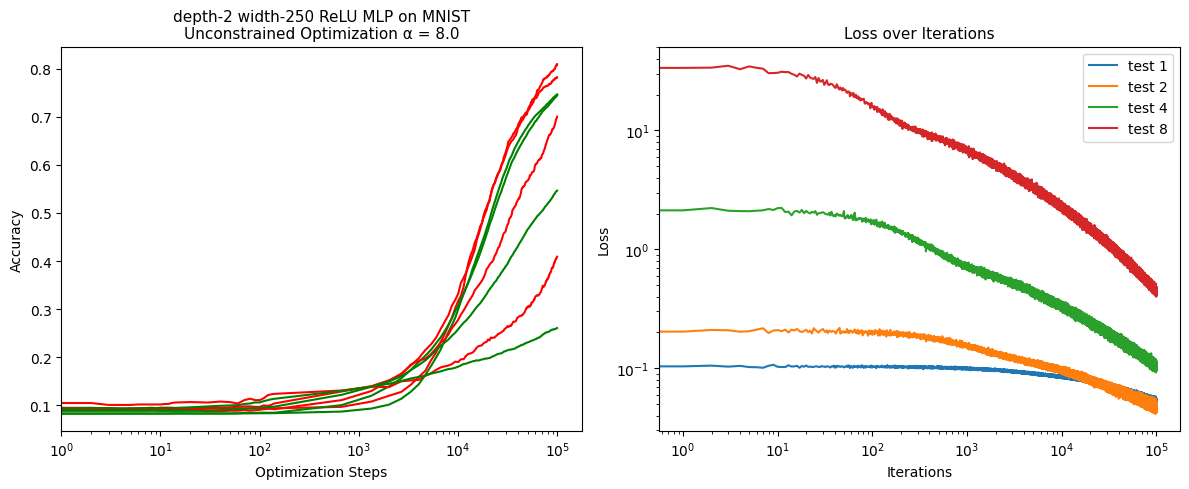

In [10]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_sgd.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_sgd[key][0]
    ax1.plot(log_steps, train_accuracies, color='red', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='green', label=f'test {key}')
    ax2.loglog(losses[:], label=f'test {key}')

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
# ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

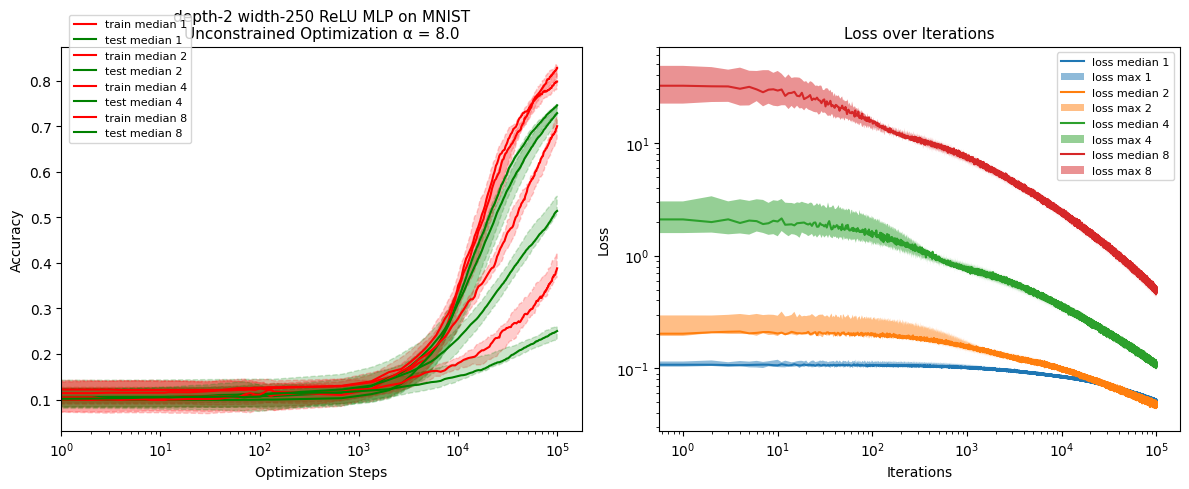

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_sgd.keys():
    # Extract data for all runs corresponding to the current scale
    all_train_accuracies = []
    all_test_accuracies = []
    all_losses = []
    all_log_steps = None  # Assume log_steps are consistent across runs

    for run in output_sgd[key]:
        train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = run
        all_train_accuracies.append(train_accuracies)
        all_test_accuracies.append(test_accuracies)
        all_losses.append(losses)
        if all_log_steps is None:
            all_log_steps = log_steps  # Use log_steps from the first run

    # Convert lists to arrays for easier computation
    all_train_accuracies = np.array(all_train_accuracies)
    all_test_accuracies = np.array(all_test_accuracies)
    all_losses = np.array(all_losses)

    # Compute min, median, and max across runs
    train_acc_min = np.min(all_train_accuracies, axis=0)
    train_acc_median = np.median(all_train_accuracies, axis=0)
    train_acc_max = np.max(all_train_accuracies, axis=0)

    test_acc_min = np.min(all_test_accuracies, axis=0)
    test_acc_median = np.median(all_test_accuracies, axis=0)
    test_acc_max = np.max(all_test_accuracies, axis=0)

    loss_min = np.min(all_losses, axis=0)
    loss_median = np.median(all_losses, axis=0)
    loss_max = np.max(all_losses, axis=0)

    # Plot accuracy statistics
    # ax1.plot(all_log_steps, train_acc_min, color='red', linestyle='--', alpha=0.5, label=f'train min {key}')
    ax1.plot(all_log_steps, train_acc_median, color='red', linestyle='-', alpha=1, label=f'train median {key}')
    ax1.fill_between(all_log_steps, train_acc_min, train_acc_max, color='red', linestyle='--', alpha=0.2)

    # ax1.plot(all_log_steps, test_acc_min, color='green', linestyle='--', alpha=0.5, label=f'test min {key}')
    ax1.plot(all_log_steps, test_acc_median, color='green', linestyle='-', alpha=1, label=f'test median {key}')
    ax1.fill_between(all_log_steps, test_acc_min, test_acc_max, color='green', linestyle='--', alpha=0.2)

    # Plot loss statistics
    # ax2.loglog(loss_min, linestyle='--', alpha=0.5, label=f'loss min {key}')
    ax2.loglog(loss_median, linestyle='-', alpha=1, label=f'loss median {key}')
    ax2.fill_between(np.arange(len(loss_min)) , loss_min, loss_max, linestyle='--', alpha=0.5, label=f'loss max {key}')

# Configure the first subplot (accuracy)
ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
ax1.legend(loc=(0.015, 0.75), fontsize=8)
ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

# Configure the second subplot (loss)
ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend(fontsize=8)
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

## Adam

In [12]:
try: 
    with open('saves/adam/adam.pkl', 'rb') as f:  # Open in binary read mode
        output_adam = pickle.load(f)
except Exception: 
    scales = [1, 2, 4, 8]
    num_iterations = [1000, 1000, 50000, 200000]
    output_adam = {}
    
    for scale, steps in zip(scales, num_iterations):
        output_adam[scale] = []
        for i in range(num_runs): 
            rng = jax.random.PRNGKey(i)
            model = MLP(depth=depth, width=width)
            state = create_train_state(rng, model, lr, weight_decay, 
                                       initialization_scale=scale, optimizer='adam')
            
            out = train_mnist_noprecond(model, state, optimization_steps=steps, log_freq=150)
            output_adam[scale].append(out)
            
    with open('saves/adam/adam.pkl', 'wb') as f:
        pickle.dump(output_adam, f)

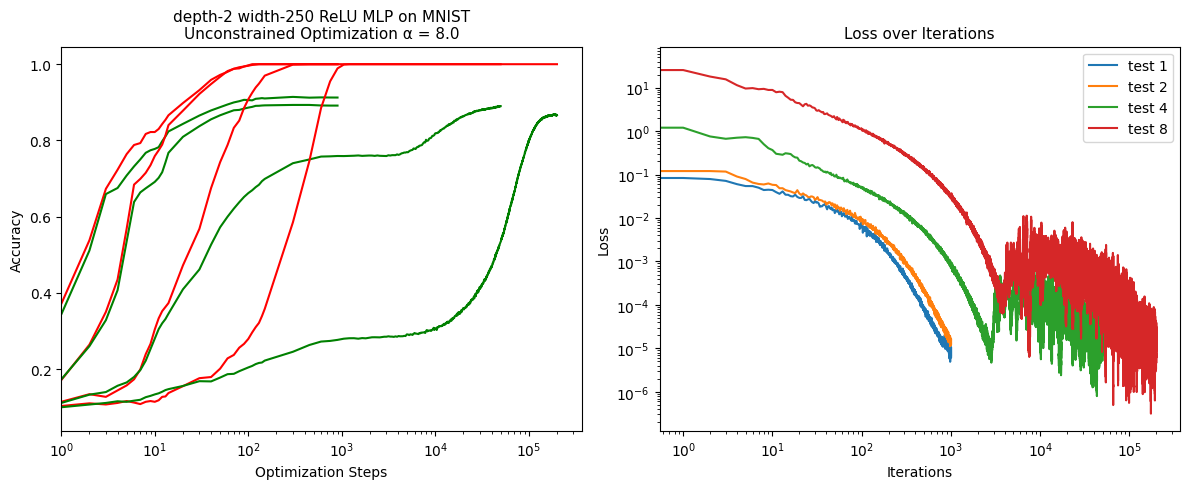

In [13]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_adam.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adam[key][0]
    ax1.plot(log_steps, train_accuracies, color='red', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='green', label=f'test {key}')
    ax2.loglog(losses[:], label=f'test {key}')

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
# ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

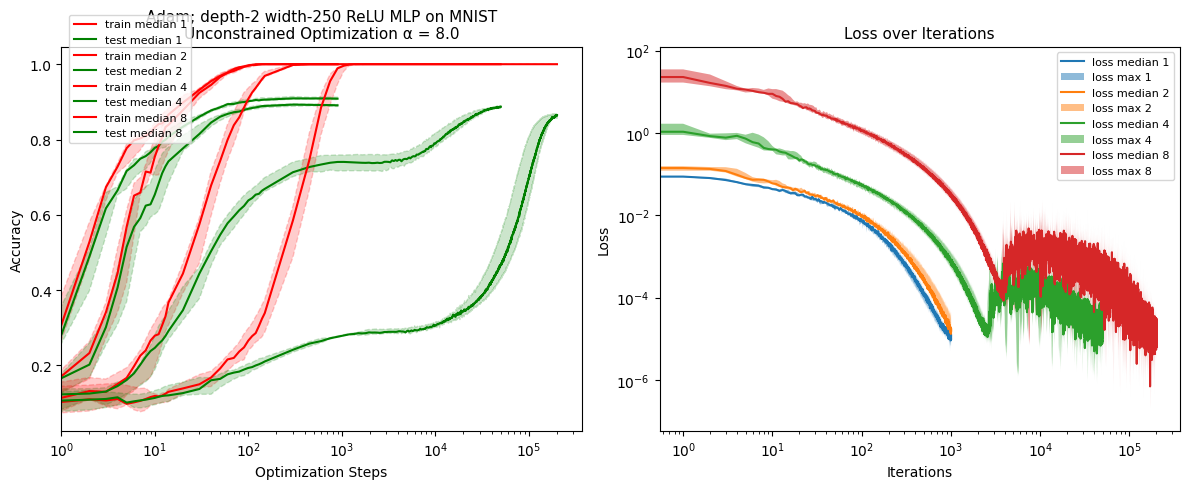

In [14]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_adam.keys():
    # Extract data for all runs corresponding to the current scale
    all_train_accuracies = []
    all_test_accuracies = []
    all_losses = []
    all_log_steps = None  # Assume log_steps are consistent across runs

    for run in output_adam[key]:
        train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = run
        all_train_accuracies.append(train_accuracies)
        all_test_accuracies.append(test_accuracies)
        all_losses.append(losses)
        if all_log_steps is None:
            all_log_steps = log_steps  # Use log_steps from the first run

    # Convert lists to arrays for easier computation
    all_train_accuracies = np.array(all_train_accuracies)
    all_test_accuracies = np.array(all_test_accuracies)
    all_losses = np.array(all_losses)

    # Compute min, median, and max across runs
    train_acc_min = np.min(all_train_accuracies, axis=0)
    train_acc_median = np.median(all_train_accuracies, axis=0)
    train_acc_max = np.max(all_train_accuracies, axis=0)

    test_acc_min = np.min(all_test_accuracies, axis=0)
    test_acc_median = np.median(all_test_accuracies, axis=0)
    test_acc_max = np.max(all_test_accuracies, axis=0)

    loss_min = np.min(all_losses, axis=0)
    loss_median = np.median(all_losses, axis=0)
    loss_max = np.max(all_losses, axis=0)

    # Plot accuracy statistics
    # ax1.plot(all_log_steps, train_acc_min, color='red', linestyle='--', alpha=0.5, label=f'train min {key}')
    ax1.plot(all_log_steps, train_acc_median, color='red', linestyle='-', alpha=1, label=f'train median {key}')
    ax1.fill_between(all_log_steps, train_acc_min, train_acc_max, color='red', linestyle='--', alpha=0.2)

    # ax1.plot(all_log_steps, test_acc_min, color='green', linestyle='--', alpha=0.5, label=f'test min {key}')
    ax1.plot(all_log_steps, test_acc_median, color='green', linestyle='-', alpha=1, label=f'test median {key}')
    ax1.fill_between(all_log_steps, test_acc_min, test_acc_max, color='green', linestyle='--', alpha=0.2)

    # Plot loss statistics
    # ax2.loglog(loss_min, linestyle='--', alpha=0.5, label=f'loss min {key}')
    ax2.loglog(loss_median, linestyle='-', alpha=1, label=f'loss median {key}')
    ax2.fill_between(np.arange(len(loss_min)) , loss_min, loss_max, linestyle='--', alpha=0.5, label=f'loss max {key}')

# Configure the first subplot (accuracy)
ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
ax1.legend(loc=(0.015, 0.75), fontsize=8)
ax1.set_title(f"Adam; depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

# Configure the second subplot (loss)
ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend(fontsize=8)
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

## AdamW 

First run with just AdamW for two seeds; we see the grokking behavior. Note that the losses wildly vary at the end while trying to learn features.

In [15]:
try: 
    with open('saves/adamw/adamw.pkl', 'rb') as f:  # Open in binary read mode
        output_adamw = pickle.load(f)
except Exception: 

    scales = [1, 2, 4, 8]
    output_adamw = {}
    
    for scale in scales: 
        output_adamw[scale] = []
        for i in range(num_runs): 
            rng = jax.random.PRNGKey(i)
            model = MLP(depth=depth, width=width)
            state = create_train_state(rng, model, lr, weight_decay, 
                                       initialization_scale=scale, optimizer='adamw')
            
            out = train_mnist_noprecond(model, state, optimization_steps=50000)
            output_adamw[scale].append(out)
    
    scales = [12]
    # output_adamw = {}
    
    for scale in scales: 
        output_adamw[scale] = []
        for i in range(num_runs): 
            rng = jax.random.PRNGKey(i)
            model = MLP(depth=depth, width=width)
            state = create_train_state(rng, model, lr, weight_decay, 
                                       initialization_scale=scale, optimizer='adamw')
            
            out = train_mnist_noprecond(model, state, optimization_steps=50000)
            output_adamw[scale].append(out)
    
    with open('saves/adamw/adamw.pkl', 'wb') as f:
        pickle.dump(output_adamw, f)

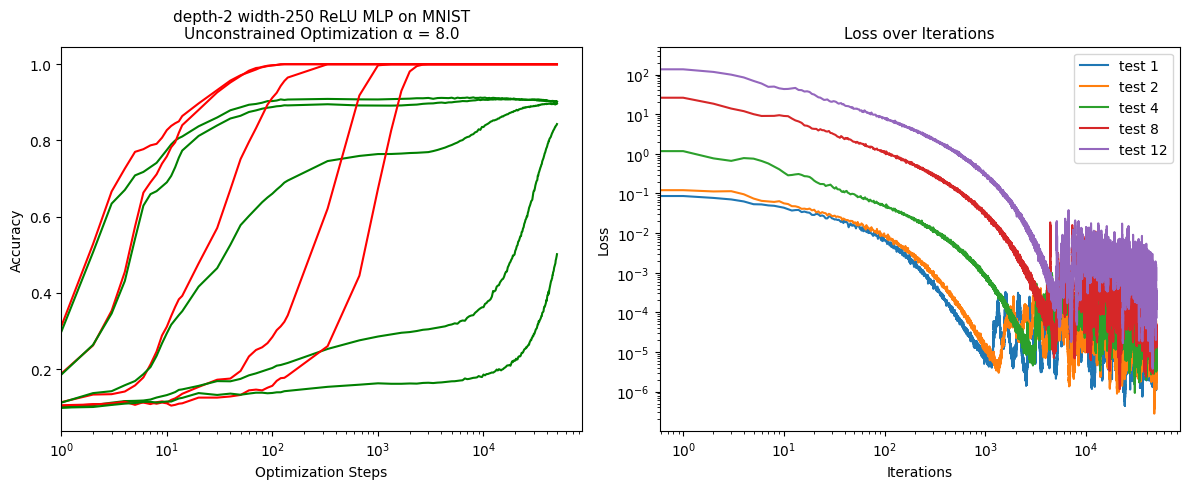

In [16]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_adamw.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw[key][0]
    ax1.plot(log_steps, train_accuracies, color='red', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='green', label=f'test {key}')
    ax2.loglog(losses[:], label=f'test {key}')

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
# ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

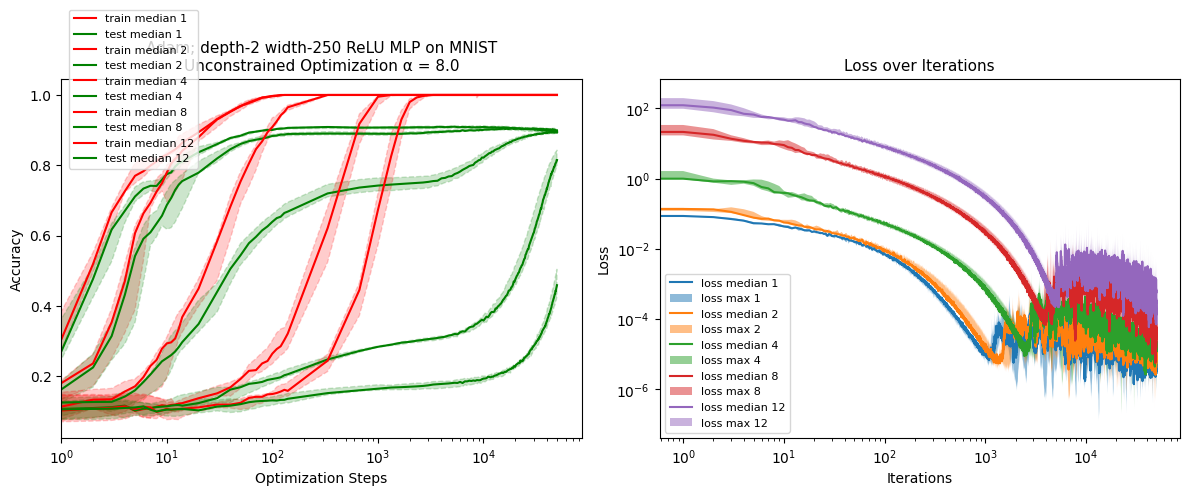

In [17]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_adamw.keys():
    # Extract data for all runs corresponding to the current scale
    all_train_accuracies = []
    all_test_accuracies = []
    all_losses = []
    all_log_steps = None  # Assume log_steps are consistent across runs

    for run in output_adamw[key]:
        train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = run
        all_train_accuracies.append(train_accuracies)
        all_test_accuracies.append(test_accuracies)
        all_losses.append(losses)
        if all_log_steps is None:
            all_log_steps = log_steps  # Use log_steps from the first run

    # Convert lists to arrays for easier computation
    all_train_accuracies = np.array(all_train_accuracies)
    all_test_accuracies = np.array(all_test_accuracies)
    all_losses = np.array(all_losses)

    # Compute min, median, and max across runs
    train_acc_min = np.min(all_train_accuracies, axis=0)
    train_acc_median = np.median(all_train_accuracies, axis=0)
    train_acc_max = np.max(all_train_accuracies, axis=0)

    test_acc_min = np.min(all_test_accuracies, axis=0)
    test_acc_median = np.median(all_test_accuracies, axis=0)
    test_acc_max = np.max(all_test_accuracies, axis=0)

    loss_min = np.min(all_losses, axis=0)
    loss_median = np.median(all_losses, axis=0)
    loss_max = np.max(all_losses, axis=0)

    # Plot accuracy statistics
    # ax1.plot(all_log_steps, train_acc_min, color='red', linestyle='--', alpha=0.5, label=f'train min {key}')
    ax1.plot(all_log_steps, train_acc_median, color='red', linestyle='-', alpha=1, label=f'train median {key}')
    ax1.fill_between(all_log_steps, train_acc_min, train_acc_max, color='red', linestyle='--', alpha=0.2)

    # ax1.plot(all_log_steps, test_acc_min, color='green', linestyle='--', alpha=0.5, label=f'test min {key}')
    ax1.plot(all_log_steps, test_acc_median, color='green', linestyle='-', alpha=1, label=f'test median {key}')
    ax1.fill_between(all_log_steps, test_acc_min, test_acc_max, color='green', linestyle='--', alpha=0.2)

    # Plot loss statistics
    # ax2.loglog(loss_min, linestyle='--', alpha=0.5, label=f'loss min {key}')
    ax2.loglog(loss_median, linestyle='-', alpha=1, label=f'loss median {key}')
    ax2.fill_between(np.arange(len(loss_min)) , loss_min, loss_max, linestyle='--', alpha=0.5, label=f'loss max {key}')

# Configure the first subplot (accuracy)
ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
ax1.legend(loc=(0.015, 0.75), fontsize=8)
ax1.set_title(f"Adam; depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

# Configure the second subplot (loss)
ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend(fontsize=8)
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

## Pure preconditioning 

Now we run with pure preconditioning; and see the reduction in grokking; however, we note that it's HIGHLY related to the learning rate, which I do not plot, and the parameter of the regularization. Generally, I found the closer it is to 0 the better, but it's a stability question. One can play the game for awhile. It doesn't reach as high of a test accuracy at the end, but we can recover that with a switch to adamw at the end, which is incredibly odd. 

Story: 
- I ran this for awhile as we can tell from the plots (note the log scale), and while the loss keeps decreasing, there is no discernible difference in test; this is somewhat different.
- We see from AdamW loss that we transition to a somewhat different loss dynamics/pattern in a more chaotic sense.
- Could it be precision issue? tested low precision in a different notebook and got similar convergence results...
- Suggests that it's more a property of the dynamics, and very delicate sensitivity to the regularization parameter; I can get higher tests if I tweak the lambda to be smaller, but that causes roughness in the lr etc etc. Would love some dynamicness to it all. 
- The dynamics is that regardless of the scaling which preconditioning pushes it all back to a similar scale, e.g. when in the NTK regime, preconditioning exhausts the NTK regime *uniformly* speed, which we can use previous plots to support, then putting us into the generalization regime.
- **I DON'T HAVE WAY TO EXPLAIN WHY IT DOESN'T CONVERGE MORE AHHHHHHHHHHHHHH**

- Two thoughts: just plain old overfitting; suggests generalization AFTER precond is actually not a weird idea. Oddly enough, get final higher test losses when moving over to Adamw
- The norm decreased for one of the thing, but it's clear that that's where the divergence is
- It's also interested to note that LM dynamics can be interpretted as weight decay; so why do we not see this? in the plots below?
- AdamW and Adam with weight decay are not the same!!! Can we do the same weight decay strategy here? Maybe that'll be good... but what's the story here? 

In [18]:
def lamb_scale(iteration, beg=1e-2,end=1e-4, steps=500): 
    if iteration >= steps:
        return end
    else:
        # # Calculate the linear interpolation
        # scale = beg + (end - beg) * (iteration / steps)
        # return scale

        # Normalize iteration to a range of [0, 1]
        t = iteration / steps
        
        # Perform logarithmic interpolation
        scale = np.exp(np.log(beg) + t * (np.log(end) - np.log(beg)))
        return scale

# Define the piecewise learning rate schedule
# schedule = optax.piecewise_interpolate_schedule('linear',
#     init_value=lr * .1, boundaries_and_scales={1000: .5, 2000: .5})
# optimizer = optax.sgd(learning_rate=schedule)
optimizer = optax.sgd(learning_rate=lr * .1)

In [19]:
try: 
    with open('saves/precond/precond.pkl', 'rb') as f:  # Open in binary read mode
        output_pure_precond = pickle.load(f)
except Exception: 
    scales = [12, 8, 4, 2, 1]
    output_pure_precond = {}
    
    for scale in scales:
        output_pure_precond[scale] = []
        for i in range(num_runs):
            rng = jax.random.PRNGKey(i)
            model = MLP(depth=depth, width=width)
            state = create_train_state(rng, model, lr, weight_decay, 
                                       initialization_scale=scale, optimizer=optimizer)
            
            out = train_mnist_precond(model, state, optimization_steps=20_000, lamb=lamb_scale)
            output_pure_precond[scale].append(out)
    
    with open('saves/precond/precond.pkl', 'wb') as f:
        pickle.dump(output_pure_precond, f)

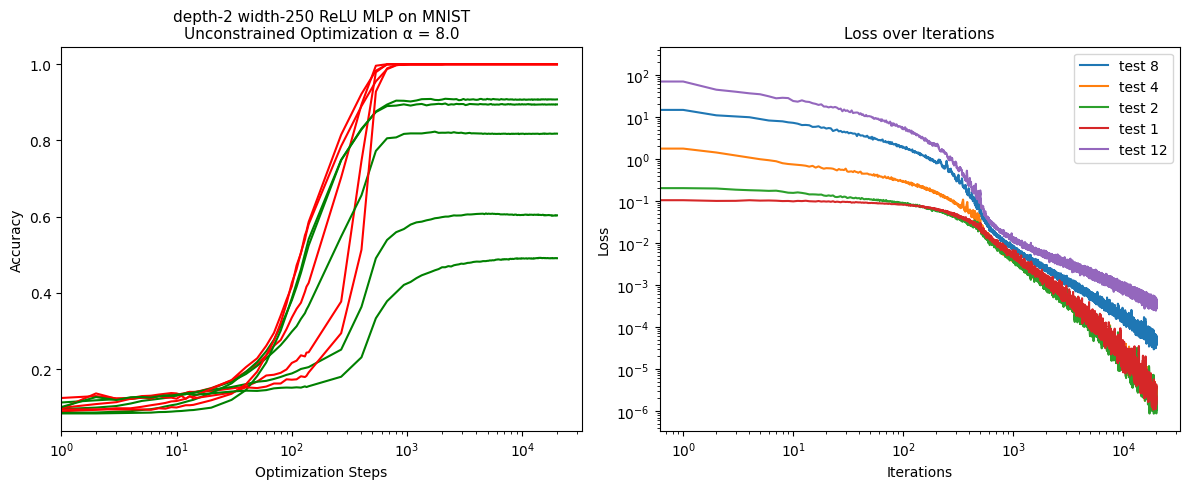

In [20]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_pure_precond.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_pure_precond[key][0]
    ax1.plot(log_steps, train_accuracies, color='red', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='green', label=f'test {key}')
    ax2.loglog(losses[:], label=f'test {key}')

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
# ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

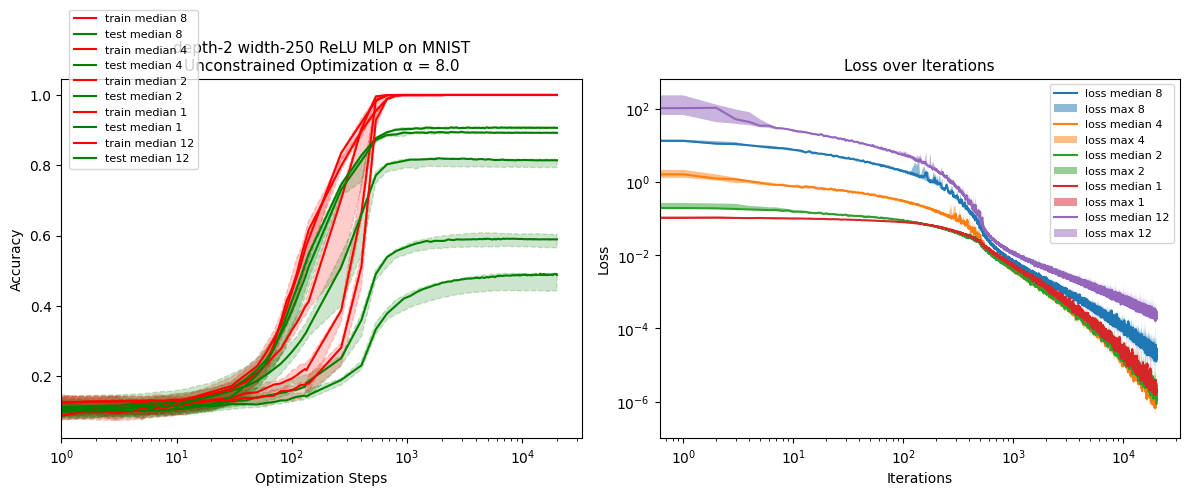

In [21]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_pure_precond.keys():
    # Extract data for all runs corresponding to the current scale
    all_train_accuracies = []
    all_test_accuracies = []
    all_losses = []
    all_log_steps = None  # Assume log_steps are consistent across runs

    for run in output_pure_precond[key]:
        train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = run
        all_train_accuracies.append(train_accuracies)
        all_test_accuracies.append(test_accuracies)
        all_losses.append(losses)
        if all_log_steps is None:
            all_log_steps = log_steps  # Use log_steps from the first run

    # Convert lists to arrays for easier computation
    all_train_accuracies = np.array(all_train_accuracies)
    all_test_accuracies = np.array(all_test_accuracies)
    all_losses = np.array(all_losses)

    # Compute min, median, and max across runs
    train_acc_min = np.min(all_train_accuracies, axis=0)
    train_acc_median = np.median(all_train_accuracies, axis=0)
    train_acc_max = np.max(all_train_accuracies, axis=0)

    test_acc_min = np.min(all_test_accuracies, axis=0)
    test_acc_median = np.median(all_test_accuracies, axis=0)
    test_acc_max = np.max(all_test_accuracies, axis=0)

    loss_min = np.min(all_losses, axis=0)
    loss_median = np.median(all_losses, axis=0)
    loss_max = np.max(all_losses, axis=0)

    # Plot accuracy statistics
    # ax1.plot(all_log_steps, train_acc_min, color='red', linestyle='--', alpha=0.5, label=f'train min {key}')
    ax1.plot(all_log_steps, train_acc_median, color='red', linestyle='-', alpha=1, label=f'train median {key}')
    ax1.fill_between(all_log_steps, train_acc_min, train_acc_max, color='red', linestyle='--', alpha=0.2)

    # ax1.plot(all_log_steps, test_acc_min, color='green', linestyle='--', alpha=0.5, label=f'test min {key}')
    ax1.plot(all_log_steps, test_acc_median, color='green', linestyle='-', alpha=1, label=f'test median {key}')
    ax1.fill_between(all_log_steps, test_acc_min, test_acc_max, color='green', linestyle='--', alpha=0.2)

    # Plot loss statistics
    # ax2.loglog(loss_min, linestyle='--', alpha=0.5, label=f'loss min {key}')
    ax2.loglog(loss_median, linestyle='-', alpha=1, label=f'loss median {key}')
    ax2.fill_between(np.arange(len(loss_min)) , loss_min, loss_max, linestyle='--', alpha=0.5, label=f'loss max {key}')

# Configure the first subplot (accuracy)
ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
ax1.legend(loc=(0.015, 0.75), fontsize=8)
ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

# Configure the second subplot (loss)
ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend(fontsize=8)
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

### Just constant lambda?

In [ ]:
scales = [8, 4, 2, 1]
output_pure_precond_nochange = {}

def lamb_scale(iteration, beg=1e-2,end=1e-5, steps=2_000): 
    if iteration >= steps:
        return end
    else:
        # # Calculate the linear interpolation
        # scale = beg + (end - beg) * (iteration / steps)
        # return scale

        # Normalize iteration to a range of [0, 1]
        t = iteration / steps
        
        # Perform logarithmic interpolation
        scale = np.exp(np.log(beg) + t * (np.log(end) - np.log(beg)))
        return scale


for scale in scales: 
    rng = jax.random.PRNGKey(0)
    model = MLP(depth=depth, width=width)
    state = create_train_state(rng, model, lr, weight_decay, 
                               initialization_scale=scale, optimizer=optimizer)
    
    out = train_mnist_precond(model, state, optimization_steps=10_000, lamb=lamb_scale)
    output_pure_precond_nochange[scale] = out

    

In [ ]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_pure_precond.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_pure_precond_nochange[key]
    ax1.plot(log_steps, train_accuracies, color='red', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='green', label=f'test {key}')
    ax2.loglog(losses[:], label=f'test {key}')

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
# ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

### can I extend and see if if i tweak the regularization up for more weight decay; it'll help? nope

In [ ]:
model = MLP(depth=depth, width=width)

def temp_lamb_scale(iteration, beg=1e-4,end=1e-6, steps=5_000): 
    if iteration >= steps:
        return end
    else:
        # # Calculate the linear interpolation
        # scale = beg + (end - beg) * (iteration / steps)
        # return scale

        # Normalize iteration to a range of [0, 1]
        t = iteration / steps
        
        # Perform logarithmic interpolation
        scale = np.exp(np.log(beg) + t * (np.log(end) - np.log(beg)))
        return scale

state = MyTrainState.create(
    apply_fn=model.apply,
    params=output_pure_precond[8][-2],
    tx=optax.sgd(lr * .1)
)
temp_out = train_mnist_precond(model, state, optimization_steps=10_000, lamb=temp_lamb_scale, log_freq=150)



## Precond with linesearch 

Let's try to fix the above with just line search

In [20]:
def lamb_scale(iteration, beg=1e-2,end=1e-4, steps=100): 
    if iteration >= steps:
        return end
    else:
        # Calculate the linear interpolation
        scale = beg + (end - beg) * (iteration / steps)
        return scale


In [21]:
# Create model
scales = [8, 4, 2, 1]
output_ls_precond = {}

for scale in scales: 
    rng = jax.random.PRNGKey(0)
    model = MLP(depth=depth, width=width)
    tx = optax.chain(
        optax.sgd(1),
        optax.scale_by_backtracking_linesearch(max_backtracking_steps=15, decrease_factor=.5)
    )

    state = create_train_state(rng, model, lr, 
                               initialization_scale=initialization_scale, optimizer=tx)

    out = train_mnist_precond(model, state, optimization_steps=5_000, log_freq=150, lamb=1e-3)
    output_ls_precond[scale] = out



Custom optimizer


  0%|          | 0/5000 [00:00<?, ?it/s]

Custom optimizer


  0%|          | 0/5000 [00:00<?, ?it/s]

Custom optimizer


  0%|          | 0/5000 [00:00<?, ?it/s]

Custom optimizer


  0%|          | 0/5000 [00:00<?, ?it/s]

In [22]:
with open('saves/linesearch/linesearch.pkl', 'wb') as f:
    pickle.dump(output_ls_precond, f)

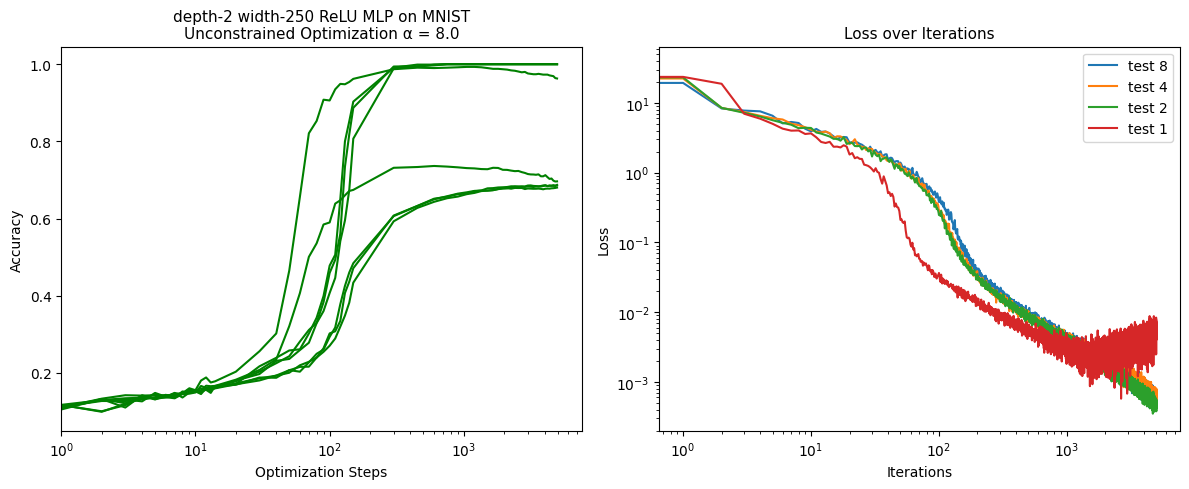

In [23]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_pure_precond.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_ls_precond[key]
    ax1.plot(log_steps, train_accuracies, color='green', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='green', label=f'test {key}')
    ax2.loglog(losses[:], label=f'test {key}')

# First subplot for accuracy
# for key in output_adamw.keys():
#     train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw[key]
#     ax1.plot(log_steps, train_accuracies, color='red', label=f'train {key}')
#     ax1.plot(log_steps, test_accuracies, color='red', label=f'test {key}')
#     ax2.loglog(losses[:], label=f'test {key}')


# for key in output_pure_precond.keys():
#     train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_pure_precond[key]
#     ax1.plot(log_steps, train_accuracies, color='blue', label=f'train {key}')
#     ax1.plot(log_steps, test_accuracies, color='blue', label=f'test {key}')
#     ax2.loglog(losses[:], label=f'test {key}')

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
# ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

## Finally, can we do AdamW after to recover? 

It's interesting that the line search converegs fast, but doesn't seem to do well after; can we just run line search for a bit then do AdamW? 

In [65]:
def lamb_scale(iteration, beg=1e-2,end=1e-4, steps=500): 
    if iteration >= steps:
        return end
    else:
        # # Calculate the linear interpolation
        # scale = beg + (end - beg) * (iteration / steps)
        # return scale

        # Normalize iteration to a range of [0, 1]
        t = iteration / steps
        
        # Perform logarithmic interpolation
        scale = np.exp(np.log(beg) + t * (np.log(end) - np.log(beg)))
        return scale

# Define the piecewise learning rate schedule
# schedule = optax.piecewise_interpolate_schedule('linear',
#     init_value=lr * .1, boundaries_and_scales={1000: .5, 2000: .5})
# optimizer = optax.sgd(learning_rate=schedule)
optimizer = optax.sgd(learning_rate=lr * .1)

In [73]:
try: 
    with open('saves/switch/switch.pkl', 'rb') as f:  # Open in binary read mode
        output_switch = pickle.load(f)
        
except Exception:
    scales = [12, 8, 4, 2, 1]
    output_switch = {}
    
    # Use parameters from pure precond above
    for scale in scales: 
        output_switch[scale] = []
        for i in range(num_runs): 
            rng = jax.random.PRNGKey(i)
            model = MLP(depth=depth, width=width)
            state = create_train_state(rng, model, lr, weight_decay, 
                                       initialization_scale=scale, optimizer=optimizer)
            
            out_1 = train_mnist_precond(model, state, optimization_steps=2_000, lamb=lamb_scale,
                                        log_freq=100)
        
            
            state = MyTrainState.create(
                apply_fn=model.apply,
                params=out_1[-2],
                tx=optax.adamw(lr, weight_decay=weight_decay)
            )
            # state = MyTrainState.create(
            #     apply_fn=model.apply,
            #     params=out_1[-2],
            #     tx=optax.sgd(lr * .01)
            # )
        
            out = train_mnist_noprecond(model, state, optimization_steps=30_000, log_freq=400)
            output_switch[scale].append((out_1, out))
    
    with open('saves/switch/switch.pkl', 'wb') as f:
        pickle.dump(output_switch, f)

Custom optimizer


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/30000 [00:00<?, ?it/s]

Custom optimizer


  0%|          | 0/2000 [00:00<?, ?it/s]

...

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/30000 [00:00<?, ?it/s]

Custom optimizer


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/30000 [00:00<?, ?it/s]

In [75]:
output_switch.keys()

dict_keys([12, 8, 4, 2, 1])

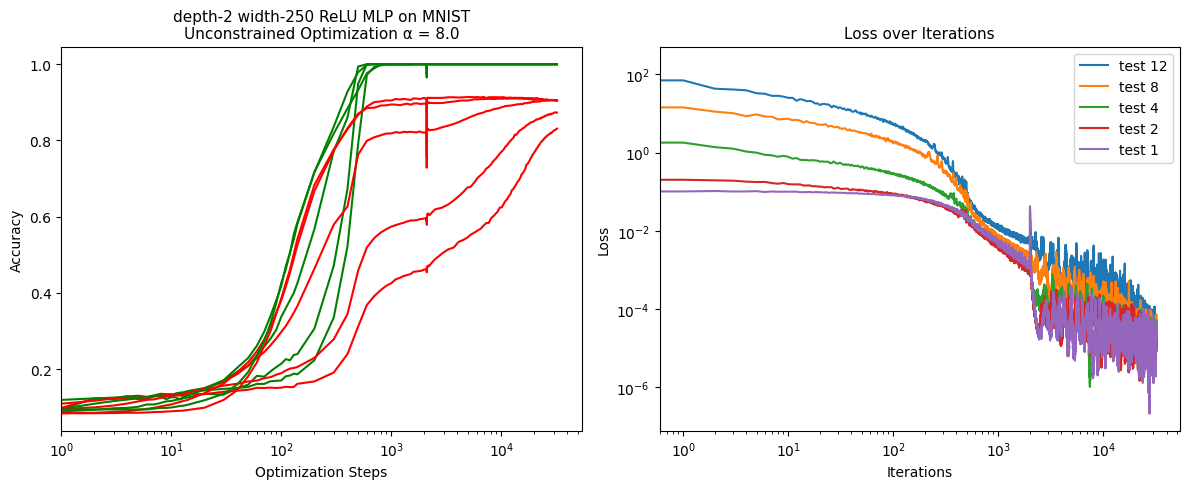

In [77]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_switch.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = combine_switch(
        *output_switch[key][0]
    )
    # train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_switch[key][0]

    ax1.plot(log_steps, train_accuracies, color='green', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='red', label=f'test {key}')
    ax2.loglog(losses[:], label=f'test {key}')


# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
# ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

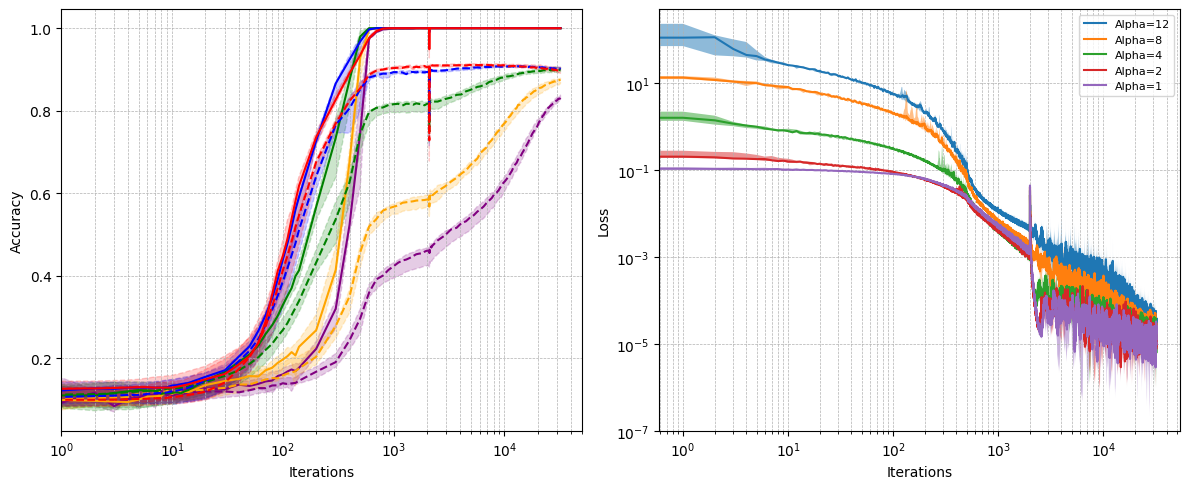

In [87]:
key_colors = {
    1: 'red',
    2: 'blue',
    4: 'green',
    8: 'orange',
    12: 'purple'
}


# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_switch.keys():
    # Extract data for all runs corresponding to the current scale
    all_train_accuracies = []
    all_test_accuracies = []
    all_losses = []
    all_log_steps = None  # Assume log_steps are consistent across runs

    for run in output_switch[key]:
        train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = combine_switch(
            *run
        )
        all_train_accuracies.append(train_accuracies)
        all_test_accuracies.append(test_accuracies)
        all_losses.append(losses)
        if all_log_steps is None:
            all_log_steps = log_steps  # Use log_steps from the first run

    # Convert lists to arrays for easier computation
    all_train_accuracies = np.array(all_train_accuracies)
    all_test_accuracies = np.array(all_test_accuracies)
    all_losses = np.array(all_losses)

    # Compute min, median, and max across runs
    train_acc_min = np.min(all_train_accuracies, axis=0)
    train_acc_median = np.median(all_train_accuracies, axis=0)
    train_acc_max = np.max(all_train_accuracies, axis=0)

    test_acc_min = np.min(all_test_accuracies, axis=0)
    test_acc_median = np.median(all_test_accuracies, axis=0)
    test_acc_max = np.max(all_test_accuracies, axis=0)

    loss_min = np.min(all_losses, axis=0)
    loss_median = np.median(all_losses, axis=0)
    loss_max = np.max(all_losses, axis=0)

    # Plot accuracy statistics
    ax1.plot(all_log_steps, train_acc_median, color=key_colors[key], linestyle='-', alpha=1, label=f'train median {key}')
    ax1.fill_between(all_log_steps, train_acc_min, train_acc_max, color=key_colors[key], linestyle='--', alpha=0.2)

    ax1.plot(all_log_steps, test_acc_median, color=key_colors[key], linestyle='dashed', alpha=1, label=f'test median {key}')
    ax1.fill_between(all_log_steps, test_acc_min, test_acc_max, color=key_colors[key], linestyle='--', alpha=0.2)

    # Plot loss statistics
    ax2.loglog(loss_median, linestyle='-', alpha=1, label=f'Alpha={key}')
    ax2.fill_between(np.arange(len(loss_min)) , loss_min, loss_max, linestyle='--', alpha=0.5)

# Configure the first subplot (accuracy)
ax1.set_xscale('log')
ax1.set_xlim(1, 5e4)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.set_xlabel("Iterations")
ax1.set_ylabel("Accuracy")

# Configure the second subplot (loss)
ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend(fontsize=8)
ax2.set_ylim(1e-7, 5e2)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig('mnist-continue.png')

# Show the plots
plt.show()

## Plotting


Try with line search instead? Line search seems to do pretty well; but missing that last bit of "OOMPF" on test data. 

### First load all the saves

In [8]:
# Load the pickle  (ran)
with open('saves/precond/precond.pkl', 'rb') as f:
    output_pure_precond = pickle.load(f)

# Load the adamw pickle file (ran)
with open('saves/adamw/adamw.pkl', 'rb') as f:
    output_adamw = pickle.load(f)

# Load the sgd pickle file
# with open('saves/sgd/sgd.pkl', 'rb') as f:
#     output_sgd = pickle.load(f)

# Load the linesearch pickle file
# with open('saves/linesearch/linesearch.pkl', 'rb') as f:
#     output_ls_precond = pickle.load(f)

# Load the switch pickle file
with open('saves/switch/switch.pkl', 'rb') as f:
    output_switch = pickle.load(f)


In [11]:
# (ran) 
with open('saves/adam/adam.pkl', 'rb') as f:
    output_adam = pickle.load(f)



### Let's see grokking 

First; we see Adam and AdamW; AdamW does much better. 

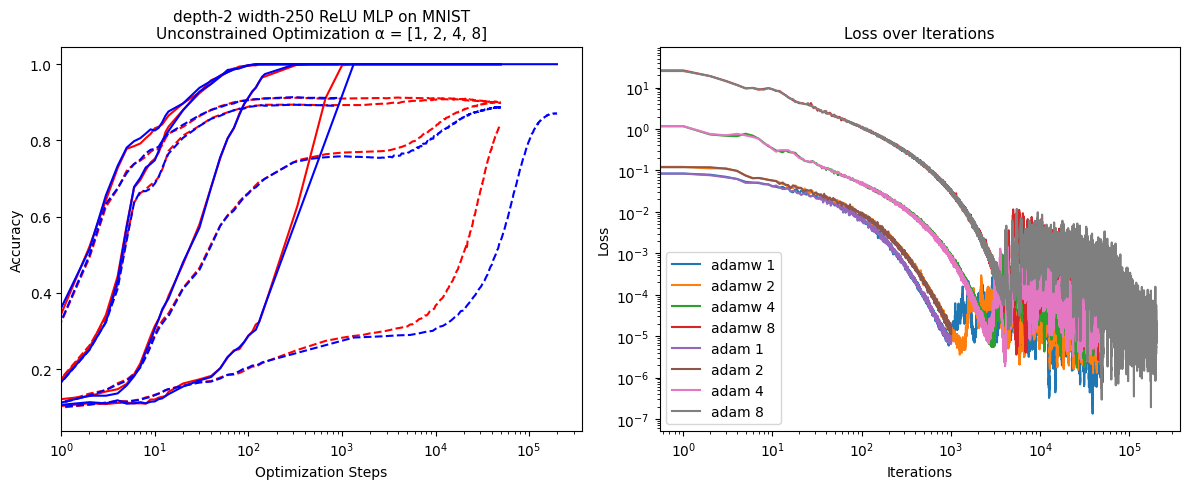

In [12]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_adamw.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw[key]
    ax1.plot(log_steps, train_accuracies, color='red', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='red', label=f'test {key}', linestyle='dashed')
    # ax3 = ax1.twinx()
    # ax3.plot(
    #     log_steps, norms, color='purple'
    # )
    ax2.loglog(losses[:], label=f'adamw {key}')

for key in output_adamw.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adam[key]
    ax1.plot(log_steps, train_accuracies, color='blue', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='blue', label=f'test {key}', linestyle='dashed')
    # ax3 = ax1.twinx()
    # ax3.plot(
    #     log_steps, norms, color='purple'
    # )
    ax2.loglog(losses[:], label=f'adam {key}')

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
# ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {[1, 2, 4, 8]}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

## Hypothesis

In NTK regime, will first explore NTK before generalizing, thus if we precondition, it'll make it such that NTK regime is explored at uniform rate (supported by theory). 

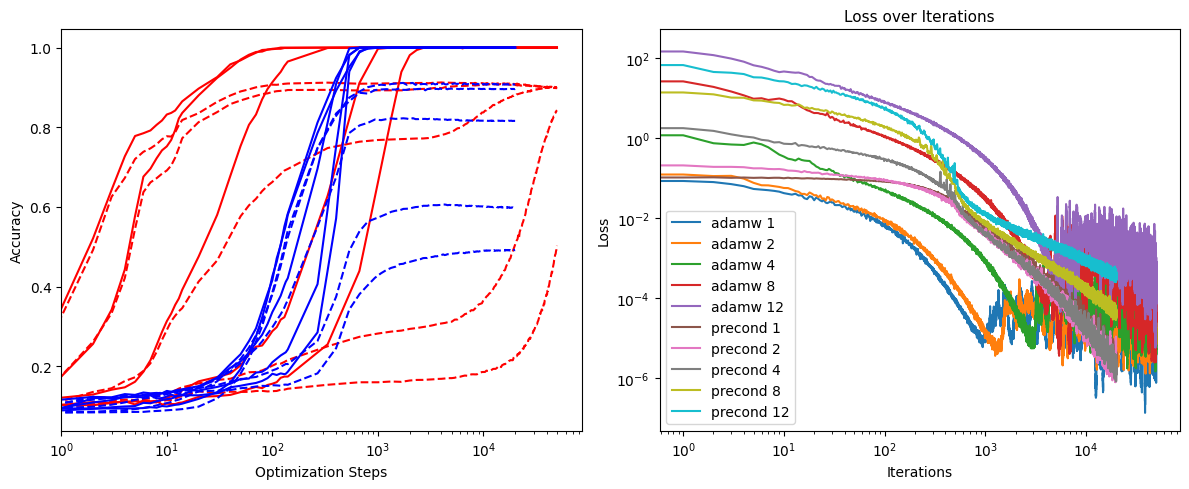

In [42]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_adamw.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw[key]
    ax1.plot(log_steps, train_accuracies, color='red', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='red', label=f'test {key}', linestyle='dashed')
    # ax3 = ax1.twinx()
    # ax3.plot(
    #     log_steps, norms, color='purple'
    # )
    ax2.loglog(losses[:], label=f'adamw {key}')

for key in output_adamw.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_pure_precond[key]
    ax1.plot(log_steps, train_accuracies, color='blue', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='blue', label=f'test {key}', linestyle='dashed')
    # ax3 = ax1.twinx()
    # ax3.plot(
    #     log_steps, norms, color='purple'
    # )
    ax2.loglog(losses[:], label=f'precond {key}')

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
# ax1.legend(loc=(0.015, 0.75))
# ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {[1, 2, 4, 8]}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()


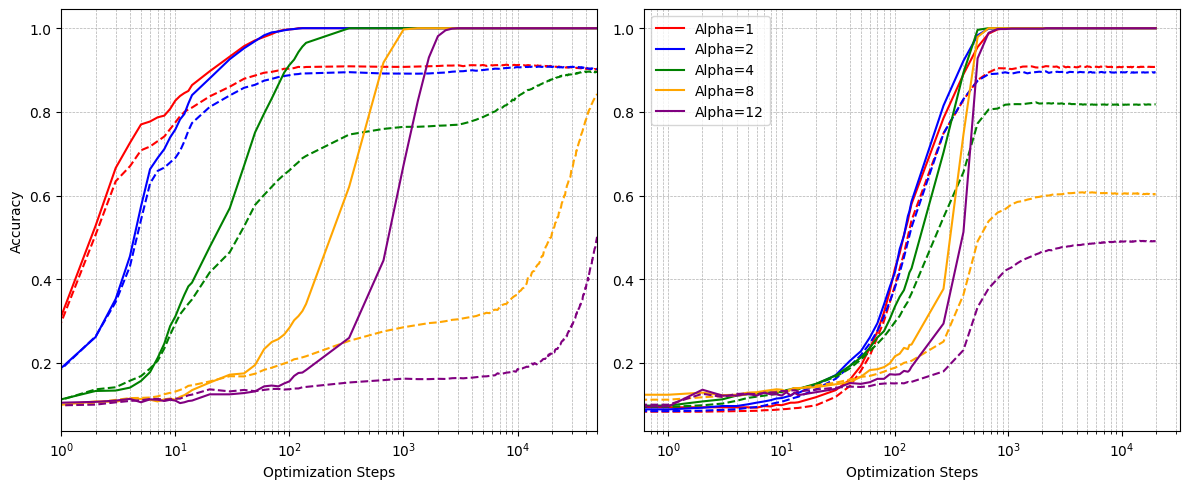

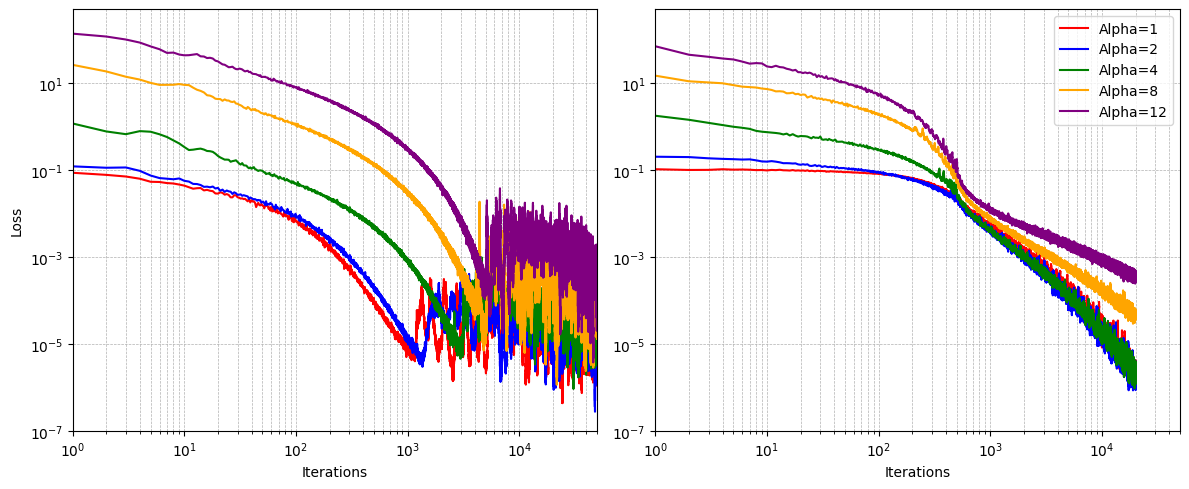

In [54]:
import matplotlib.pyplot as plt

# Define a consistent color mapping for the keys
key_colors = {
    1: 'red',
    2: 'blue',
    4: 'green',
    8: 'orange',
    12: 'purple'
}

# First figure: Accuracy on left and right panes
fig1, (ax1_left, ax1_right) = plt.subplots(1, 2, figsize=(12, 5))

# Left pane: Accuracy for AdamW
for key in [1, 2, 4, 8, 12]:
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw[key][0]
    ax1_left.plot(log_steps, train_accuracies, color=key_colors[key], label=f'Alpha {key}')
    ax1_left.plot(log_steps, test_accuracies, color=key_colors[key], label=f'test {key}', linestyle='dashed')

ax1_left.set_xscale('log')
ax1_left.set_xlim(1, 5e4)
ax1_left.set_xlabel("Optimization Steps")
ax1_left.set_ylabel("Accuracy")
ax1_left.grid(True, which='both', linestyle='--', linewidth=0.5)

# ax1_left.legend()
# ax1_left.set_title("Accuracy (AdamW and Preconditioned)")

# Right pane: Accuracy for Preconditioned
for key in [1, 2, 4, 8, 12]:
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_pure_precond[key][0]
    ax1_right.plot(log_steps, train_accuracies, color=key_colors[key], label=f'Alpha={key}')
    ax1_right.plot(log_steps, test_accuracies, color=key_colors[key], linestyle='dashed')

ax1_right.set_xscale('log')
ax1_left.set_xlim(1, 5e4)
ax1_right.set_xlabel("Optimization Steps")
# ax1_right.set_ylabel("Accuracy")
ax1_right.legend()
ax1_right.grid(True, which='both', linestyle='--', linewidth=0.5)

# ax1_right.set_title("Accuracy (AdamW and Preconditioned)")

plt.tight_layout()
plt.savefig('mnist-accuracy.png')
plt.show()

# Second figure: Loss on left and right panes
fig2, (ax2_left, ax2_right) = plt.subplots(1, 2, figsize=(12, 5))

# Left pane: Loss for AdamW
for key in [1, 2, 4, 8, 12]:
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw[key][0]
    ax2_left.loglog(losses[:], color=key_colors[key], label=f'adamw {key}')

ax2_left.set_xlabel("Iterations")
ax2_left.set_ylabel("Loss")
ax2_left.set_xlim(1, 5e4)
ax2_left.set_ylim(1e-7, 5e2)
ax2_left.grid(True, which='both', linestyle='--', linewidth=0.5)

# ax2_left.legend()
# ax2_left.set_title("Loss (AdamW)")

# Right pane: Loss for Preconditioned
for key in [1, 2, 4, 8, 12]:
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_pure_precond[key][0]
    ax2_right.loglog(losses[:], color=key_colors[key],label=f'Alpha={key}')

ax2_right.set_xlabel("Iterations")
# ax2_right.set_ylabel("Loss")
ax2_right.set_xlim(1, 5e4)
ax2_right.set_ylim(1e-7, 5e2)
ax2_right.grid(True, which='both', linestyle='--', linewidth=0.5)

ax2_right.legend()
# ax2_right.set_title("Loss (Preconditioned)")

plt.tight_layout()
plt.savefig('mnist-loss.png')

plt.show()


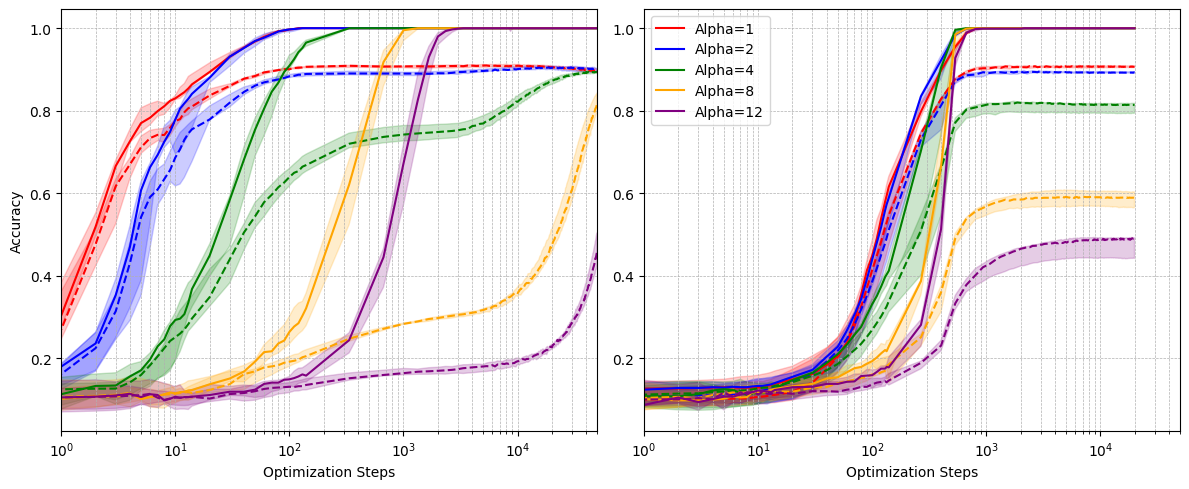

In [59]:
# Define a consistent color mapping for the keys
key_colors = {
    1: 'red',
    2: 'blue',
    4: 'green',
    8: 'orange',
    12: 'purple'
}

# Helper function to compute min, max, and median across seeds
def compute_statistics(data):
    data = np.array(data)  # Convert to numpy array for easier manipulation
    min_vals = np.min(data, axis=0)
    max_vals = np.max(data, axis=0)
    median_vals = np.median(data, axis=0)
    return min_vals, max_vals, median_vals

# First figure: Accuracy on left and right panes
fig1, (ax1_left, ax1_right) = plt.subplots(1, 2, figsize=(12, 5))

# Left pane: Accuracy for AdamW
for key in [1, 2, 4, 8, 12]:
    train_accuracies_all_seeds = [output_adamw[key][seed][2] for seed in range(len(output_adamw[key]))]
    test_accuracies_all_seeds = [output_adamw[key][seed][3] for seed in range(len(output_adamw[key]))]
    log_steps = output_adamw[key][0][4]  # Assume log_steps is the same across seeds

    # Compute statistics
    train_min, train_max, train_median = compute_statistics(train_accuracies_all_seeds)
    test_min, test_max, test_median = compute_statistics(test_accuracies_all_seeds)

    # Plot shaded regions for min/max and median lines
    ax1_left.fill_between(log_steps, train_min, train_max, color=key_colors[key], alpha=0.2)
    ax1_left.plot(log_steps, train_median, color=key_colors[key], label=f'Train {key}')
    ax1_left.fill_between(log_steps, test_min, test_max, color=key_colors[key], alpha=0.2)
    ax1_left.plot(log_steps, test_median, color=key_colors[key], label=f'Test {key}', linestyle='dashed')

ax1_left.set_xscale('log')
ax1_left.set_xlim(1, 5e4)
ax1_left.set_xlabel("Optimization Steps")
ax1_left.set_ylabel("Accuracy")
ax1_left.grid(True, which='both', linestyle='--', linewidth=0.5)

# Right pane: Accuracy for Preconditioned
for key in [1, 2, 4, 8, 12]:
    train_accuracies_all_seeds = [output_pure_precond[key][seed][2] for seed in range(len(output_pure_precond[key]))]
    test_accuracies_all_seeds = [output_pure_precond[key][seed][3] for seed in range(len(output_pure_precond[key]))]
    log_steps = output_pure_precond[key][0][4]  # Assume log_steps is the same across seeds

    # Compute statistics
    train_min, train_max, train_median = compute_statistics(train_accuracies_all_seeds)
    test_min, test_max, test_median = compute_statistics(test_accuracies_all_seeds)

    # Plot shaded regions for min/max and median lines
    ax1_right.fill_between(log_steps, train_min, train_max, color=key_colors[key], alpha=0.2)
    ax1_right.plot(log_steps, train_median, color=key_colors[key], label=f'Alpha={key}')
    ax1_right.fill_between(log_steps, test_min, test_max, color=key_colors[key], alpha=0.2)
    ax1_right.plot(log_steps, test_median, color=key_colors[key], linestyle='dashed')

ax1_right.set_xscale('log')
ax1_right.set_xlim(1, 5e4)
ax1_right.set_xlabel("Optimization Steps")
ax1_right.legend()
ax1_right.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig('mnist-accuracy.png')
plt.show()

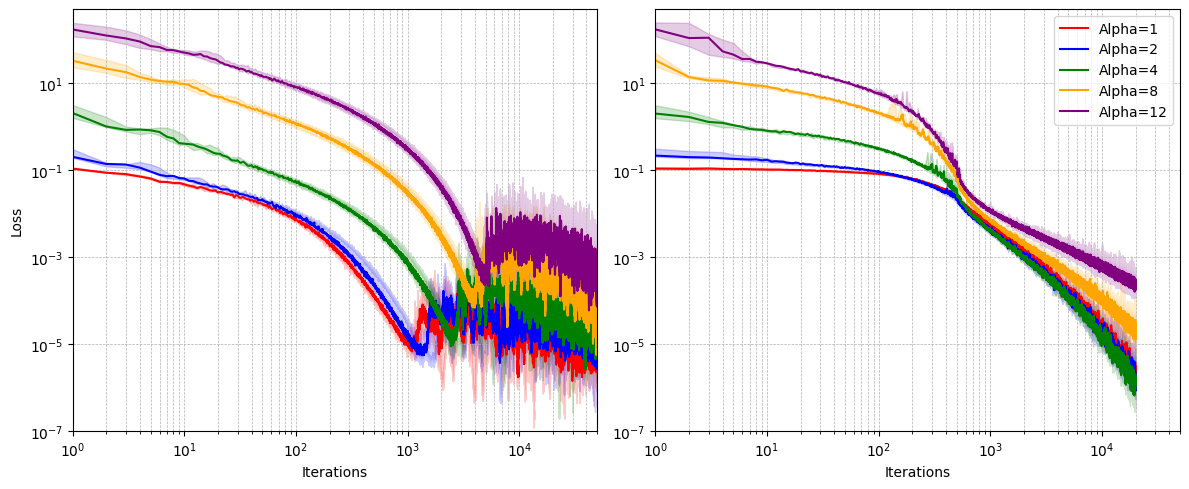

In [64]:
# Second figure: Loss on left and right panes
fig2, (ax2_left, ax2_right) = plt.subplots(1, 2, figsize=(12, 5))

# Left pane: Loss for AdamW
for key in [1, 2, 4, 8, 12]:
    losses_all_seeds = [output_adamw[key][seed][5] for seed in range(len(output_adamw[key]))]
    log_steps = output_adamw[key][0][4]  # Assume log_steps is the same across seeds

    # Compute statistics
    losses_min, losses_max, losses_median = compute_statistics(losses_all_seeds)

    # Plot shaded regions for min/max and median lines
    ax2_left.fill_between(np.arange(1, len(losses_min) + 1), losses_min, losses_max, color=key_colors[key], alpha=0.2)
    ax2_left.loglog(np.arange(1, len(losses_min) + 1), losses_median, color=key_colors[key], label=f'AdamW {key}')

ax2_left.set_xlabel("Iterations")
ax2_left.set_ylabel("Loss")
ax2_left.set_xlim(1, 5e4)
ax2_left.set_ylim(1e-7, 5e2)
ax2_left.grid(True, which='both', linestyle='--', linewidth=0.5)

# Right pane: Loss for Preconditioned
for key in [1, 2, 4, 8, 12]:
    losses_all_seeds = [output_pure_precond[key][seed][5] for seed in range(len(output_pure_precond[key]))]
    log_steps = output_pure_precond[key][0][4]  # Assume log_steps is the same across seeds

    # Compute statistics
    losses_min, losses_max, losses_median = compute_statistics(losses_all_seeds)

    # Plot shaded regions for min/max and median lines
    ax2_right.fill_between(np.arange(1, len(losses_min) + 1), losses_min, losses_max, color=key_colors[key], alpha=0.2)
    ax2_right.loglog(np.arange(1, len(losses_min) + 1), losses_median, color=key_colors[key], label=f'Alpha={key}')

ax2_right.set_xlabel("Iterations")
ax2_right.set_xlim(1, 5e4)
ax2_right.set_ylim(1e-7, 5e2)
ax2_right.grid(True, which='both', linestyle='--', linewidth=0.5)

ax2_right.legend()

plt.tight_layout()
plt.savefig('mnist-loss.png')
plt.show()

## However, note that our test accuracy is not increasing steadily at all even as the loss keeps decrasing

WHy is this? Can we recover this? By switching on AdamW at the end? 

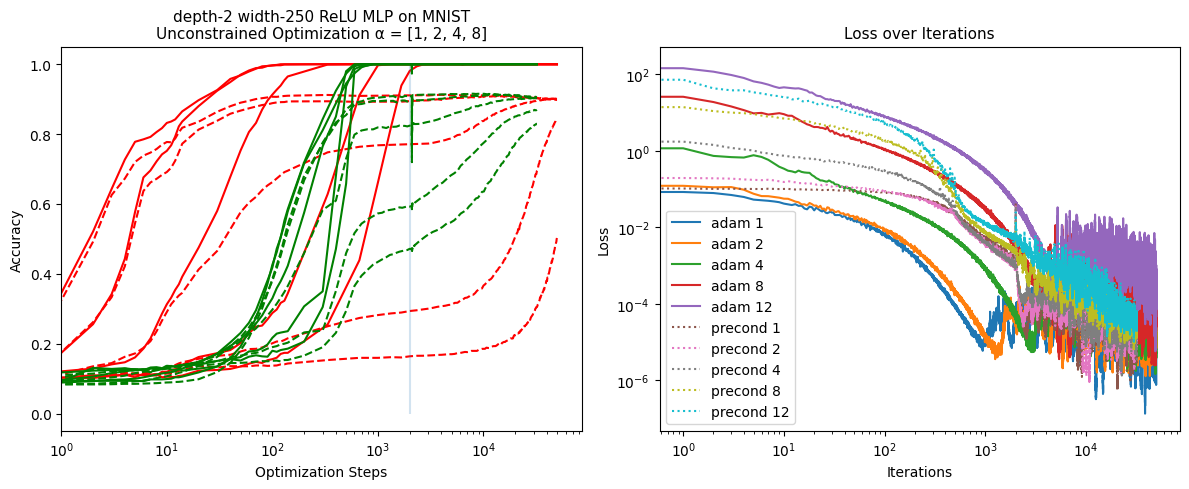

In [41]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# # First subplot for accuracy
for key in output_adamw.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw[key]
    ax1.plot(log_steps, train_accuracies, color='red', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='red', label=f'test {key}', linestyle='dashed')
    ax2.loglog(losses[:], label=f'adam {key}')

ax1.vlines([2_000], 0, 1, alpha=.2)

# First subplot for accuracy
for key in [1, 2, 4, 8, 12]:
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = combine_switch(
        *output_switch[key]
    )

    ax1.plot(log_steps, train_accuracies, color='green', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='green', label=f'test {key}', linestyle='dashed')
    ax2.loglog(losses[:], label=f'precond {key}', linestyle='dotted')

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
# ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {[1, 2, 4, 8]}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

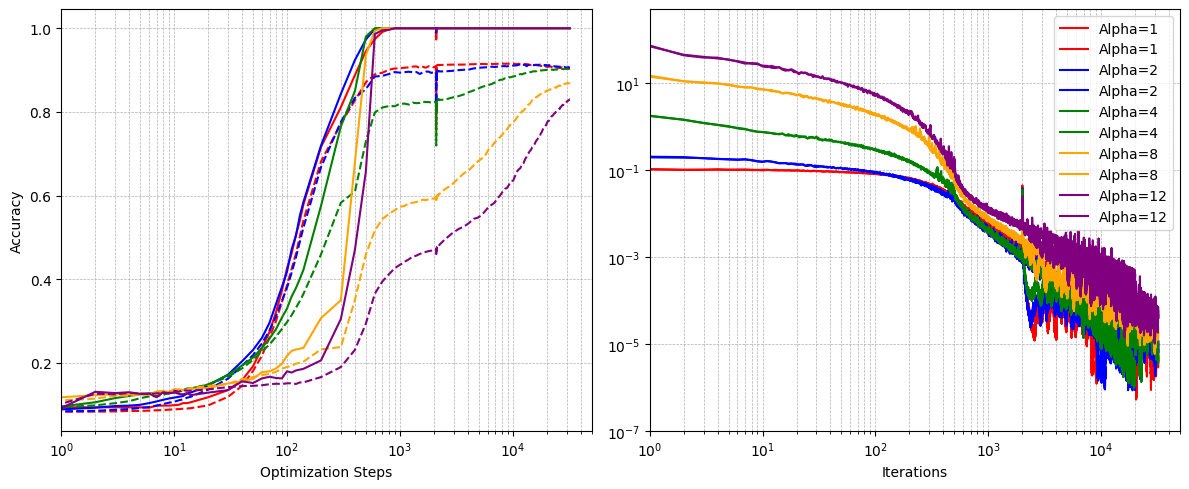

In [49]:
import matplotlib.pyplot as plt

# Define a consistent color mapping for the keys
key_colors = {
    1: 'red',
    2: 'blue',
    4: 'green',
    8: 'orange',
    12: 'purple'
}

# First figure: Accuracy on left and right panes
fig1, (ax1_left, ax1_right) = plt.subplots(1, 2, figsize=(12, 5))

for key in [1, 2, 4, 8, 12]:
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = combine_switch(
        *output_switch[key]
    )
    ax1_left.plot(log_steps, train_accuracies, color=key_colors[key], label=f'Alpha={key}')
    ax1_left.plot(log_steps, test_accuracies, color=key_colors[key], linestyle='dashed')

ax1_left.set_xscale('log')
ax1_left.set_xlim(1, 5e4)
ax1_left.set_xlabel("Optimization Steps")
ax1_left.set_ylabel("Accuracy")
ax1_left.grid(True, which='both', linestyle='--', linewidth=0.5)


# Right pane: Loss for Preconditioned
for key in [1, 2, 4, 8, 12]:
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = combine_switch(
        *output_switch[key]
    )
    ax1_right.loglog(losses[:], color=key_colors[key],label=f'Alpha={key}')

    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_pure_precond[key][0]
    ax1_right.loglog(losses[:], color=key_colors[key],label=f'Alpha={key}')


ax1_right.set_xlabel("Iterations")
# ax2_right.set_ylabel("Loss")
ax1_right.set_xlim(1, 5e4)
ax1_right.set_ylim(1e-7, 5e2)
ax1_right.grid(True, which='both', linestyle='--', linewidth=0.5)

ax1_right.legend()
# ax2_right.set_title("Loss (Preconditioned)")

plt.tight_layout()
# plt.savefig('mnist-continue.png')

plt.show()


### Seems to be related to the weights... 

But does the preconditioned not help with weight decay? 

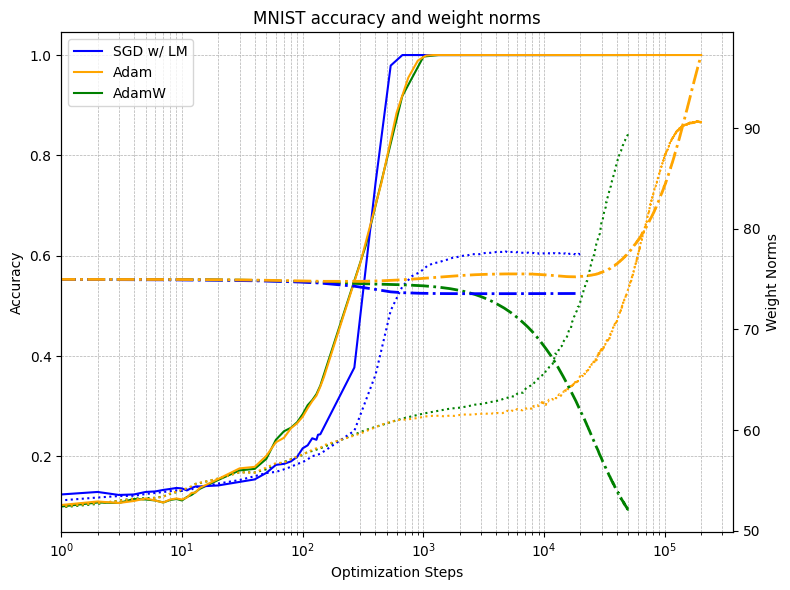

In [42]:
import matplotlib.pyplot as plt

# Create a figure with a single subplot
fig, ax1 = plt.subplots(figsize=(8, 6))

# Define the keys to iterate over
keys = [8]

# Set a color palette
colors = {
    'adamw_train': 'green',
    'adamw_test': 'green',
    'pure_precond_train': 'blue',
    'pure_precond_test': 'blue',
    'adam_train': 'orange',
    'adam_test': 'orange',
    'norms_adamw': 'green',
    'norms_pure_precond': 'blue',
    'norms_adam': 'orange'
}

# Plot data from output_adamw
for key in keys:
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw[key][0]
    ax1.plot(log_steps, train_accuracies, color=colors['adamw_train'], label=f'Train {key} (AdamW)')
    ax1.plot(log_steps, test_accuracies, color=colors['adamw_test'], label=f'Test {key} (AdamW)', linestyle='dotted')

# Plot data from output_pure_precond
for key in keys:
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_pure_precond[key][0]
    ax1.plot(log_steps, train_accuracies, color=colors['pure_precond_train'], label=f'Train {key} (Pure Preconditioner)')
    ax1.plot(log_steps, test_accuracies, color=colors['pure_precond_test'], label=f'Test {key} (Pure Preconditioner)', linestyle='dotted')

# Plot data from output_adam
for key in keys:
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adam[key][0]
    ax1.plot(log_steps, train_accuracies, color=colors['adam_train'], label=f'Train {key} (Adam)')
    ax1.plot(log_steps, test_accuracies, color=colors['adam_test'], label=f'Test {key} (Adam)', linestyle='dotted')

# Create a secondary y-axis for norms
ax2 = ax1.twinx()

# Plot norms on the secondary y-axis
for key in keys:
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw[key][0]
    ax2.semilogx(log_steps, norms, color=colors['norms_adamw'], label=f'Norms {key} (AdamW)', linestyle='dashdot', linewidth=2)

    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_pure_precond[key][0]
    ax2.semilogx(log_steps, norms, color=colors['norms_pure_precond'], label=f'Norms {key} (Pure Preconditioner)', linestyle='dashdot', linewidth=2)

    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adam[key][0]
    ax2.semilogx(log_steps, norms, color=colors['norms_adam'], label=f'Norms {key} (Adam)', linestyle='dashdot', linewidth=2)

# Set axis properties for the first y-axis
ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
ax1.set_title("MNIST accuracy and weight norms")

# Set axis properties for the second y-axis
ax2.set_ylabel("Weight Norms")

# Add grid lines
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

handles = [
    plt.Line2D([0], [0], color='blue', label='SGD w/ LM'),
    plt.Line2D([0], [0], color='orange', label='Adam'),
    plt.Line2D([0], [0], color='green', label='AdamW')
]

# Add the legend
ax1.legend(handles=handles, loc='upper left')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig('mnist-weight.png')

# Show the plot
plt.show()


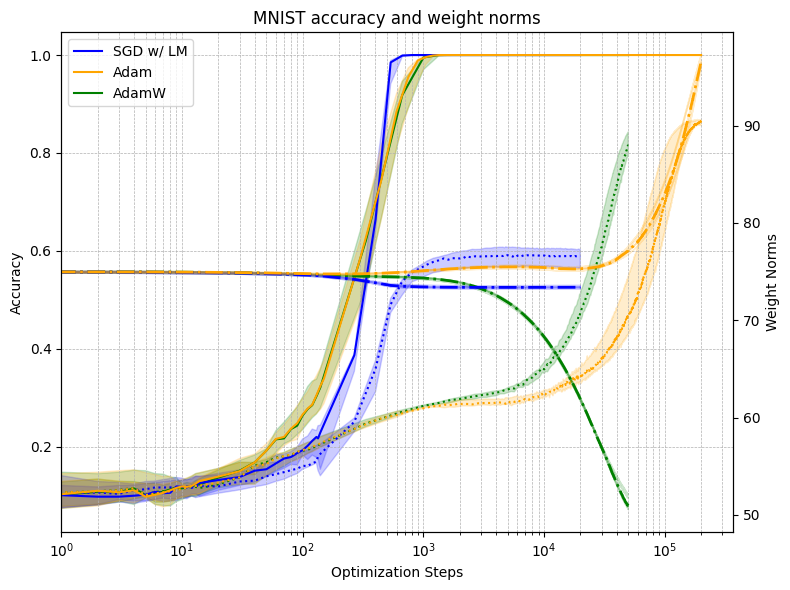

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Create a figure with a single subplot
fig, ax1 = plt.subplots(figsize=(8, 6))

# Define the keys to iterate over
keys = [8]

# Set a color palette
colors = {
    'adamw_train': 'green',
    'adamw_test': 'green',
    'pure_precond_train': 'blue',
    'pure_precond_test': 'blue',
    'adam_train': 'orange',
    'adam_test': 'orange',
    'norms_adamw': 'green',
    'norms_pure_precond': 'blue',
    'norms_adam': 'orange'
}

# Helper function to compute min, max, and median across seeds
def compute_statistics(data):
    data = np.array(data)  # Convert to numpy array for easier manipulation
    min_vals = np.min(data, axis=0)
    max_vals = np.max(data, axis=0)
    median_vals = np.median(data, axis=0)
    return min_vals, max_vals, median_vals

# Plot data from output_adamw
for key in keys:
    train_accuracies_all_seeds = [output_adamw[key][seed][2] for seed in range(len(output_adamw[key]))]
    test_accuracies_all_seeds = [output_adamw[key][seed][3] for seed in range(len(output_adamw[key]))]
    log_steps = output_adamw[key][0][4]  # Assume log_steps is the same across seeds

    # Compute statistics
    train_min, train_max, train_median = compute_statistics(train_accuracies_all_seeds)
    test_min, test_max, test_median = compute_statistics(test_accuracies_all_seeds)

    # Plot shaded regions for min/max and median lines
    ax1.fill_between(log_steps, train_min, train_max, color=colors['adamw_train'], alpha=0.2)
    ax1.plot(log_steps, train_median, color=colors['adamw_train'], label=f'Train {key} (AdamW)')
    ax1.fill_between(log_steps, test_min, test_max, color=colors['adamw_test'], alpha=0.2)
    ax1.plot(log_steps, test_median, color=colors['adamw_test'], label=f'Test {key} (AdamW)', linestyle='dotted')

# Plot data from output_pure_precond
for key in keys:
    train_accuracies_all_seeds = [output_pure_precond[key][seed][2] for seed in range(len(output_pure_precond[key]))]
    test_accuracies_all_seeds = [output_pure_precond[key][seed][3] for seed in range(len(output_pure_precond[key]))]
    log_steps = output_pure_precond[key][0][4]  # Assume log_steps is the same across seeds

    # Compute statistics
    train_min, train_max, train_median = compute_statistics(train_accuracies_all_seeds)
    test_min, test_max, test_median = compute_statistics(test_accuracies_all_seeds)

    # Plot shaded regions for min/max and median lines
    ax1.fill_between(log_steps, train_min, train_max, color=colors['pure_precond_train'], alpha=0.2)
    ax1.plot(log_steps, train_median, color=colors['pure_precond_train'], label=f'Train {key} (Pure Preconditioner)')
    ax1.fill_between(log_steps, test_min, test_max, color=colors['pure_precond_test'], alpha=0.2)
    ax1.plot(log_steps, test_median, color=colors['pure_precond_test'], label=f'Test {key} (Pure Preconditioner)', linestyle='dotted')

# Plot data from output_adam
for key in keys:
    train_accuracies_all_seeds = [output_adam[key][seed][2] for seed in range(len(output_adam[key]))]
    test_accuracies_all_seeds = [output_adam[key][seed][3] for seed in range(len(output_adam[key]))]
    log_steps = output_adam[key][0][4]  # Assume log_steps is the same across seeds

    # Compute statistics
    train_min, train_max, train_median = compute_statistics(train_accuracies_all_seeds)
    test_min, test_max, test_median = compute_statistics(test_accuracies_all_seeds)

    # Plot shaded regions for min/max and median lines
    ax1.fill_between(log_steps, train_min, train_max, color=colors['adam_train'], alpha=0.2)
    ax1.plot(log_steps, train_median, color=colors['adam_train'], label=f'Train {key} (Adam)')
    ax1.fill_between(log_steps, test_min, test_max, color=colors['adam_test'], alpha=0.2)
    ax1.plot(log_steps, test_median, color=colors['adam_test'], label=f'Test {key} (Adam)', linestyle='dotted')

# Create a secondary y-axis for norms
ax2 = ax1.twinx()

# Plot norms on the secondary y-axis
for key in keys:
    # Extract norms and log_steps for AdamW
    norms_all_seeds_adamw = [output_adamw[key][seed][7] for seed in range(len(output_adamw[key]))]
    log_steps_all_seeds_adamw = [output_adamw[key][seed][4] for seed in range(len(output_adamw[key]))]

    # Plot individual runs
    for norms, log_steps in zip(norms_all_seeds_adamw, log_steps_all_seeds_adamw):
        ax2.fill_between(log_steps, norms, norms, color=colors['norms_adamw'], alpha=0.2)  # Min/Max are the same for individual runs

    # Compute and plot the median
    norms_median_adamw = np.median(np.array(norms_all_seeds_adamw), axis=0)
    ax2.semilogx(log_steps_all_seeds_adamw[0], norms_median_adamw, color=colors['norms_adamw'], label=f'Norms {key} (AdamW)', linestyle='dashdot', linewidth=2)

    # Extract norms and log_steps for Pure Preconditioner
    norms_all_seeds_pure_precond = [output_pure_precond[key][seed][7] for seed in range(len(output_pure_precond[key]))]
    log_steps_all_seeds_pure_precond = [output_pure_precond[key][seed][4] for seed in range(len(output_pure_precond[key]))]

    # Plot individual runs
    for norms, log_steps in zip(norms_all_seeds_pure_precond, log_steps_all_seeds_pure_precond):
        ax2.fill_between(log_steps, norms, norms, color=colors['norms_pure_precond'], alpha=0.2)  # Min/Max are the same for individual runs

    # Compute and plot the median
    norms_median_pure_precond = np.median(np.array(norms_all_seeds_pure_precond), axis=0)
    ax2.semilogx(log_steps_all_seeds_pure_precond[0], norms_median_pure_precond, color=colors['norms_pure_precond'], label=f'Norms {key} (Pure Preconditioner)', linestyle='dashdot', linewidth=2)

    # Extract norms and log_steps for Adam
    norms_all_seeds_adam = [output_adam[key][seed][7] for seed in range(len(output_adam[key]))]
    log_steps_all_seeds_adam = [output_adam[key][seed][4] for seed in range(len(output_adam[key]))]

    # Plot individual runs
    for norms, log_steps in zip(norms_all_seeds_adam, log_steps_all_seeds_adam):
        ax2.fill_between(log_steps, norms, norms, color=colors['norms_adam'], alpha=0.2)  # Min/Max are the same for individual runs

    # Compute and plot the median
    norms_median_adam = np.median(np.array(norms_all_seeds_adam), axis=0)
    ax2.semilogx(log_steps_all_seeds_adam[0], norms_median_adam, color=colors['norms_adam'], label=f'Norms {key} (Adam)', linestyle='dashdot', linewidth=2)        
# Set axis properties for the first y-axis
ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
ax1.set_title("MNIST accuracy and weight norms")

# Set axis properties for the second y-axis
ax2.set_ylabel("Weight Norms")

# Add grid lines
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

handles = [
    plt.Line2D([0], [0], color='blue', label='SGD w/ LM'),
    plt.Line2D([0], [0], color='orange', label='Adam'),
    plt.Line2D([0], [0], color='green', label='AdamW')
]

# Add the legend
ax1.legend(handles=handles, loc='upper left')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig('mnist-weight.png')

# Show the plot
plt.show()